# DDPM CRAB real-observation prediction

This notebook runs DDPM reconstruction on LHAASO CRAB experimental data without GT reference.

It combines the useful parts of previous notebooks:

- single-image CRAB `.npy` loading from `data/CRAB`
- repeated stochastic DDPM generation and per-sample visualization
- pixel-wise uncertainty maps from multiple DDPM samples
- manually selected reverse-diffusion timestep snapshots
- final visualization in both plain and enhanced styles
- FWHM measurements for the input observation and selected reconstruction


In [1]:
from pathlib import Path
import importlib
import json
import math
import sys
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from matplotlib.colors import PowerNorm
from scipy.ndimage import map_coordinates
from tqdm.auto import tqdm

plt.rcParams["figure.dpi"] = 120


def find_repo_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "codes").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError("Could not find repo root containing codes/ and data/.")


ADDR_ROOT = find_repo_root()
ADDR_CODE = ADDR_ROOT / "codes"
ADDR_MODELS = ADDR_CODE / "models"
for repo_path in [ADDR_ROOT, ADDR_CODE, ADDR_MODELS]:
    repo_path_str = str(repo_path)
    if repo_path_str not in sys.path:
        sys.path.append(repo_path_str)

from codes.config.config_DDPM import ModelConfig

print(f"ADDR_ROOT = {ADDR_ROOT}")
print(f"CUDA available = {torch.cuda.is_available()}")


ADDR_ROOT = /root/LHAI_KM2A
CUDA available = True


/root/miniconda3/envs/LHAI/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. User configuration

Set the CRAB file, matching DDPM weight, number of repeated samples, selected final sample, and timestep snapshots here.


In [2]:
CRAB_DIR = ADDR_ROOT / "data" / "CRAB"
CRAB_NPY_NAME = "SS433_64_KM2AE25.npy"
CRAB_NPY_PATH = None
SAMPLE_INDEX = 0
INPUT_CHANNEL = None
SAMPLE_SELECTOR = None

MODEL_WEIGHT_DIR = ADDR_ROOT / "saves" / "MODEL" / "DDPM"
MODEL_WEIGHT_NAME = "Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.pth"
MODEL_WEIGHT_PATH = None

DIFFUSION_CONFIG_KEY = "DDPM_64"
DIFFUSION_MODULE_NAME = "DDPM"
DIFFUSION_CLASS_NAME = "DDPM"
UNET_CONFIG_KEY = "UNET"
UNET_MODULE_NAME = "UNET"
UNET_CLASS_NAME = "UNET"

DATA_RANGE = 2.0
BASE_SEED = 2026
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
STRICT_LOAD = True
CLAMP_OUTPUT = False
OVERRIDE_IMG_SIZE_FROM_DATA = True

N_SAMPLES = 20
SAMPLE_BATCH_SIZE = 4
FINAL_SAMPLE_INDEX = 0
SAVE_EACH_SAMPLE_FIGURE = True

CUSTOM_SNAPSHOT_STEPS = [1999, 100, 90, 80, 70, 60, 50, 40, 30, 20, 10, 5, 0]
SAVE_PREDICTED_NOISE = True

COUNTS_RESTORE_MODE = "input_mass_match"
CLIP_FOR_COUNTS = True
EPS_COUNTS = 1e-8

FWHM_CENTER_MODE = "peak"
FWHM_CENTER_YX = None
FWHM_RADIAL_BIN_WIDTH = 1.0
LINE_SEGMENT = None
LINE_PROFILE_SAMPLES = 160

VIS_CMAP_IMAGE = "viridis"
VIS_CMAP_RESIDUAL = "coolwarm"
VIS_CMAP_UNCERTAINTY = "inferno"
VIS_CMAP_NOISE = "RdBu_r"
ENHANCED_COUNTS_STYLE = True
CONTOUR_PERCENTILES = (70, 82, 90, 96)
QUIVER_STRIDE = 6
QUIVER_SCALE = None

ENERGY_RANGE = "1TeV~10TeV"
ROI_DESCRIPTION = "6.4 deg square centered at CRAB; source-map construction follows LHAASO CRAB experimental data"
SAVE_OUTPUTS = True
OUTPUT_DIR = ADDR_ROOT / "saves" / "PREDICT" / "DDPM" / "CRAB"


In [3]:
def show_available_files():
    crab_files = sorted(CRAB_DIR.glob("*.npy")) if CRAB_DIR.exists() else []
    weight_files = sorted(MODEL_WEIGHT_DIR.glob("*.pth")) if MODEL_WEIGHT_DIR.exists() else []
    print("Available CRAB .npy files:")
    for file_path in crab_files:
        print(f"  {file_path.name}")
    if not crab_files:
        print(f"  No .npy files found in {CRAB_DIR}")
    print("\nAvailable DDPM weights:")
    for file_path in weight_files:
        print(f"  {file_path.name}")
    print("\nExperiment metadata:")
    print(f"  energy range: {ENERGY_RANGE}")
    print(f"  ROI: {ROI_DESCRIPTION}")


show_available_files()

if CRAB_NPY_PATH is None:
    if CRAB_NPY_NAME is None:
        raise ValueError("Set CRAB_NPY_NAME or CRAB_NPY_PATH.")
    crab_path = CRAB_DIR / CRAB_NPY_NAME
else:
    crab_path = Path(CRAB_NPY_PATH)

if MODEL_WEIGHT_PATH is None:
    if MODEL_WEIGHT_NAME is None:
        raise ValueError("Set MODEL_WEIGHT_NAME or MODEL_WEIGHT_PATH.")
    model_weight_path = MODEL_WEIGHT_DIR / MODEL_WEIGHT_NAME
else:
    model_weight_path = Path(MODEL_WEIGHT_PATH)

if not crab_path.exists():
    raise FileNotFoundError(crab_path)
if not model_weight_path.exists():
    raise FileNotFoundError(model_weight_path)

print(f"Selected CRAB data: {crab_path}")
print(f"Selected model weight: {model_weight_path}")


Available CRAB .npy files:
  CRAB_1to20_excess_128.npy
  CRAB_1to20_excess_64.npy
  CRAB_1to20_on_128.npy
  CRAB_1to20_on_64.npy
  CRAB_64.npy
  CRAB_64_KM2AE25.npy
  CRAB_64_poissonexcess.npy
  CRAB_64_poissonon.npy
  EXP4_4_64_conv.npy
  EXP4_4_64_poissonexcess.npy
  G1503_64.npy
  GRS1915_64.npy
  GRS1915_64_KM2AE25.npy
  HESS_2_64_Predict_version2poissonexcess.npy
  J1915_64_poissonexcess.npy
  J1915_64_poissonon.npy
  SS433_64.npy
  SS433_64_KM2AE25.npy
  TestSource_bkgon_64.npy
  TestSource_excess_64.npy

Available DDPM weights:
  Best_DDPM_EXP01_2epo_32bth_SR4poissonexcess.pth
  Best_DDPM_EXP01_400epo_128bth_KM2A4eval.pth
  Best_DDPM_KM2AE25_100epo_64bth_KM2A4poisonexcess.pth
  Best_DDPM_KM2AE25_2epo_64bth_KM2A4poisonexcess.pth
  Best_DDPM_KM2AE25_400epo_64bth_KM2A4poisonexcess.pth
  Best_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.pth
  Best_DDPM_KM2AE25v2_600epo_64bth_KM2A4poisonexcess.pth
  Best_DDPM_KM2A_1000epo_32bth_SR4poissonexcess.pth
  Best_DDPM_KM2A_400epo_32bth_SR4

## 2. Load a single CRAB image

CRAB files are expected to be single `(n, n)` maps. The loader also accepts `(N, H, W)`, `(C, H, W)`, or `(N, C, H, W)` if future CRAB files are batched.


In [4]:
def as_float32(array):
    return np.asarray(array, dtype=np.float32)


def select_image_from_array(array, sample_index=0, channel=None, selector=None):
    array = np.asarray(array)
    if selector is not None:
        selected = array[tuple(selector)]
        if selected.ndim == 2:
            return as_float32(selected)
        if selected.ndim == 3 and channel is not None and selected.shape[0] <= 8:
            return as_float32(selected[channel])
        raise ValueError(f"SAMPLE_SELECTOR must select a 2D image, got {selected.shape}")
    if array.ndim == 2:
        return as_float32(array)
    if array.ndim == 3:
        if array.shape[0] <= 8 and array.shape[1] == array.shape[2] and channel is not None:
            return as_float32(array[channel])
        if sample_index >= array.shape[0]:
            raise IndexError(f"SAMPLE_INDEX={sample_index} out of range for shape {array.shape}")
        return as_float32(array[sample_index])
    if array.ndim == 4:
        if sample_index >= array.shape[0]:
            raise IndexError(f"SAMPLE_INDEX={sample_index} out of range for shape {array.shape}")
        sample = array[sample_index]
        if channel is None:
            channel = 0 if sample.shape[0] == 1 else 1
        return as_float32(sample[channel])
    raise ValueError(f"Expected (H,W), (N,H,W), (C,H,W), or (N,C,H,W), got {array.shape}")


def minmax_normalize_image(image, data_range=1.0):
    image = as_float32(image)
    vmin = float(np.nanmin(image))
    vmax = float(np.nanmax(image))
    norm01 = (image - vmin) / max(vmax - vmin, 1e-8)
    if abs(data_range - 1.0) < 1e-6:
        return norm01.astype(np.float32), vmin, vmax
    if abs(data_range - 2.0) < 1e-6:
        return (2.0 * norm01 - 1.0).astype(np.float32), vmin, vmax
    raise ValueError("DATA_RANGE must be 1.0 or 2.0")


def normalized_to_unit_interval(array):
    array = np.asarray(array, dtype=np.float32)
    if abs(DATA_RANGE - 2.0) < 1e-6:
        unit = 0.5 * (array + 1.0)
    elif abs(DATA_RANGE - 1.0) < 1e-6:
        unit = array
    else:
        raise ValueError("DATA_RANGE must be 1.0 or 2.0")
    return np.clip(unit, 0.0, 1.0) if CLIP_FOR_COUNTS else unit


def resize_2d(image, size):
    image = as_float32(image)
    if image.shape == (size, size):
        return image
    tensor = torch.from_numpy(image[None, None]).float()
    return F.interpolate(tensor, size=(size, size), mode="bilinear", align_corners=False)[0, 0].numpy()


crab_array = np.load(crab_path, allow_pickle=True)
input_counts = select_image_from_array(crab_array, SAMPLE_INDEX, INPUT_CHANNEL, SAMPLE_SELECTOR)
input_norm, input_min, input_max = minmax_normalize_image(input_counts, DATA_RANGE)

print(f"CRAB array shape: {np.asarray(crab_array).shape}")
print(f"selected input shape: {input_counts.shape}, min={input_counts.min():.4g}, max={input_counts.max():.4g}, sum={input_counts.sum():.4g}")
print(f"normalized input range: ({input_norm.min():.4g}, {input_norm.max():.4g})")


CRAB array shape: (64, 64)
selected input shape: (64, 64), min=-8.624, max=75.15, sum=1.875e+04
normalized input range: (-1, 1)


## 3. Load DDPM model and shared restore/FWHM utilities


In [5]:
def import_model_class(module_name, class_name):
    module = importlib.import_module(f"codes.models.{module_name}")
    return getattr(module, class_name)


model_cfg = ModelConfig()
model_params = model_cfg.model_params
condition_size = int(input_norm.shape[-1])
if input_norm.shape[-1] != input_norm.shape[-2]:
    raise ValueError(f"Input image must be square for DDPM, got {input_norm.shape}")

if DIFFUSION_CONFIG_KEY is None:
    if condition_size == 128 and "DDPM128" in model_params:
        DIFFUSION_CONFIG_KEY = "DDPM128"
    elif condition_size == 64 and "DDPM_64" in model_params:
        DIFFUSION_CONFIG_KEY = "DDPM_64"
    else:
        raise KeyError("Could not infer DIFFUSION_CONFIG_KEY. Set it manually.")

params_diffusion = dict(model_params[DIFFUSION_CONFIG_KEY])
params_unet = dict(model_params[UNET_CONFIG_KEY])
image_size = int(params_diffusion.get("img_size", condition_size))
if OVERRIDE_IMG_SIZE_FROM_DATA and params_diffusion.get("img_size") != condition_size:
    print(f"Overriding diffusion img_size from {params_diffusion.get('img_size')} to input size {condition_size}.")
    image_size = condition_size
    params_diffusion["img_size"] = image_size
params_diffusion["device"] = torch.device(DEVICE)

device = torch.device(DEVICE)
DIFFUSION = import_model_class(DIFFUSION_MODULE_NAME, DIFFUSION_CLASS_NAME)
UNET = import_model_class(UNET_MODULE_NAME, UNET_CLASS_NAME)

diffusion = DIFFUSION(**params_diffusion)
unet = UNET(**params_unet).to(device)
if hasattr(unet, "build"):
    unet.build()
unet.to(device)
state = torch.load(model_weight_path, map_location=device)
if isinstance(state, dict) and "state_dict" in state:
    state = state["state_dict"]
unet.load_state_dict(state, strict=STRICT_LOAD)
unet.eval()

condition_norm = resize_2d(input_norm, image_size)
condition_tensor = torch.from_numpy(condition_norm[None, None]).float().to(device)
input_counts_resized = resize_2d(input_counts, image_size)


def restore_counts_from_normalized(norm_array, *, reference_counts=None, min_value=None, max_value=None, mode="mass_match"):
    unit = normalized_to_unit_interval(norm_array)
    if mode == "minmax":
        if min_value is None or max_value is None:
            raise ValueError("minmax restore requires min_value and max_value.")
        return unit * max(max_value - min_value, EPS_COUNTS) + min_value
    if mode == "mass_match":
        if reference_counts is None:
            raise ValueError("mass_match restore requires reference_counts.")
        unit = np.clip(unit, 0.0, None)
        reference_mass = np.clip(np.asarray(reference_counts, dtype=np.float32), 0.0, None).sum()
        if unit.ndim == 2:
            return unit * (reference_mass / max(unit.sum(), EPS_COUNTS))
        unit_mass = unit.reshape(unit.shape[0], -1).sum(axis=1).reshape((-1,) + (1,) * (unit.ndim - 1))
        return unit * (reference_mass / np.maximum(unit_mass, EPS_COUNTS))
    raise ValueError("mode must be 'minmax' or 'mass_match'.")


def restore_norm_to_counts(image_norm):
    if COUNTS_RESTORE_MODE == "input_minmax":
        return restore_counts_from_normalized(image_norm, min_value=input_min, max_value=input_max, mode="minmax")
    if COUNTS_RESTORE_MODE == "input_mass_match":
        return restore_counts_from_normalized(image_norm, reference_counts=input_counts_resized, mode="mass_match")
    raise ValueError("COUNTS_RESTORE_MODE must be input_minmax or input_mass_match for no-GT CRAB prediction")


def image_flux(image):
    return float(np.clip(np.asarray(image), 0.0, None).sum())


def choose_center(image, mode=FWHM_CENTER_MODE):
    if FWHM_CENTER_YX is not None:
        return tuple(FWHM_CENTER_YX)
    if mode == "peak":
        return np.unravel_index(int(np.nanargmax(image)), image.shape)
    if mode == "center":
        return ((image.shape[0] - 1) / 2.0, (image.shape[1] - 1) / 2.0)
    raise ValueError("FWHM_CENTER_MODE must be 'peak' or 'center', or set FWHM_CENTER_YX.")


def radial_profile(image, center_yx=None, bin_width=1.0):
    image = np.asarray(image, dtype=np.float64)
    center_yx = choose_center(image) if center_yx is None else center_yx
    yy, xx = np.indices(image.shape)
    rr = np.sqrt((yy - center_yx[0]) ** 2 + (xx - center_yx[1]) ** 2)
    bins = np.floor(rr / bin_width).astype(int)
    nbins = int(bins.max()) + 1
    profile = np.full(nbins, np.nan, dtype=np.float64)
    radii = (np.arange(nbins) + 0.5) * bin_width
    for b in range(nbins):
        mask = bins == b
        if np.any(mask):
            profile[b] = image[mask].mean()
    return radii, profile, center_yx


def fwhm_from_image(image, center_yx=None, bin_width=1.0):
    radii, profile, center_yx = radial_profile(image, center_yx, bin_width)
    peak = np.nanmax(profile)
    if not np.isfinite(peak) or peak <= 0:
        return float("nan")
    half = 0.5 * peak
    valid = np.where(np.isfinite(profile) & (profile <= half))[0]
    if valid.size == 0:
        return float("nan")
    first = int(valid[0])
    if first == 0:
        radius_half = radii[0]
    else:
        x0, x1 = radii[first - 1], radii[first]
        y0, y1 = profile[first - 1], profile[first]
        radius_half = x1 if y1 == y0 else x0 + (half - y0) * (x1 - x0) / (y1 - y0)
    return float(2.0 * radius_half)


print(f"Device: {device}")
print(f"Diffusion config key: {DIFFUSION_CONFIG_KEY}")
print(f"noise_steps: {diffusion.noise_steps}")
print(f"Image size: {image_size}")
print(f"Condition tensor shape: {tuple(condition_tensor.shape)}")


Device: cuda
Diffusion config key: DDPM_64
noise_steps: 2000
Image size: 64
Condition tensor shape: (1, 1, 64, 64)


## 4. Repeated DDPM generation and uncertainty

Each sample is visualized separately. The sample index in these figures is the same index used by `FINAL_SAMPLE_INDEX` later.


Sampling: 100%|██████████| 2000/2000 [00:03<00:00, 593.63it/s]


Saved sample figure: /root/LHAI_KM2A/saves/PREDICT/DDPM/CRAB/sample_000__SS433_64_KM2AE25__Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.png


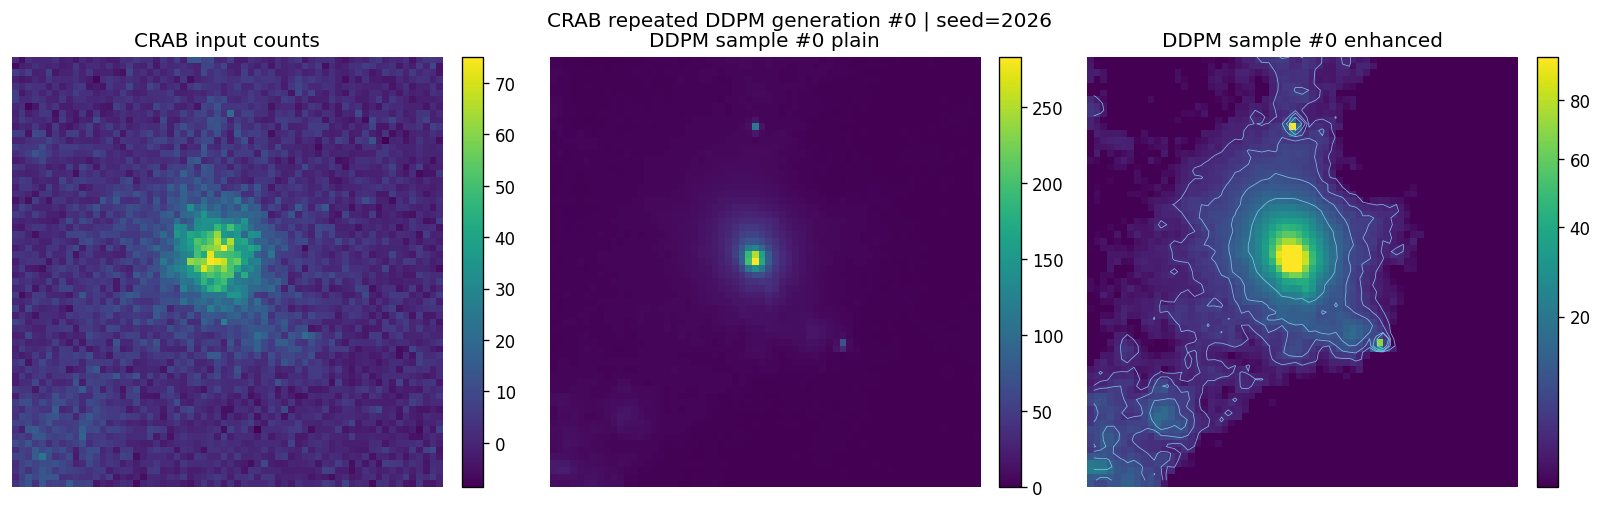

Sampling: 100%|██████████| 2000/2000 [00:03<00:00, 641.67it/s]


Saved sample figure: /root/LHAI_KM2A/saves/PREDICT/DDPM/CRAB/sample_001__SS433_64_KM2AE25__Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.png


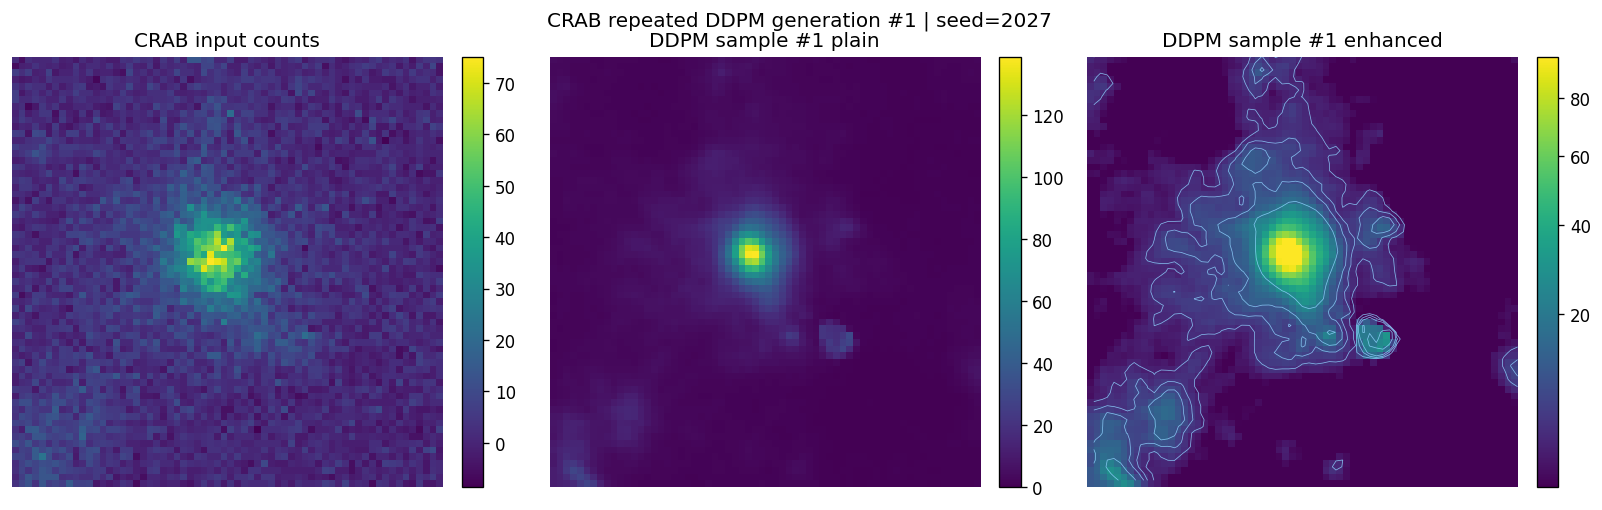

Sampling: 100%|██████████| 2000/2000 [00:03<00:00, 653.53it/s]


Saved sample figure: /root/LHAI_KM2A/saves/PREDICT/DDPM/CRAB/sample_002__SS433_64_KM2AE25__Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.png


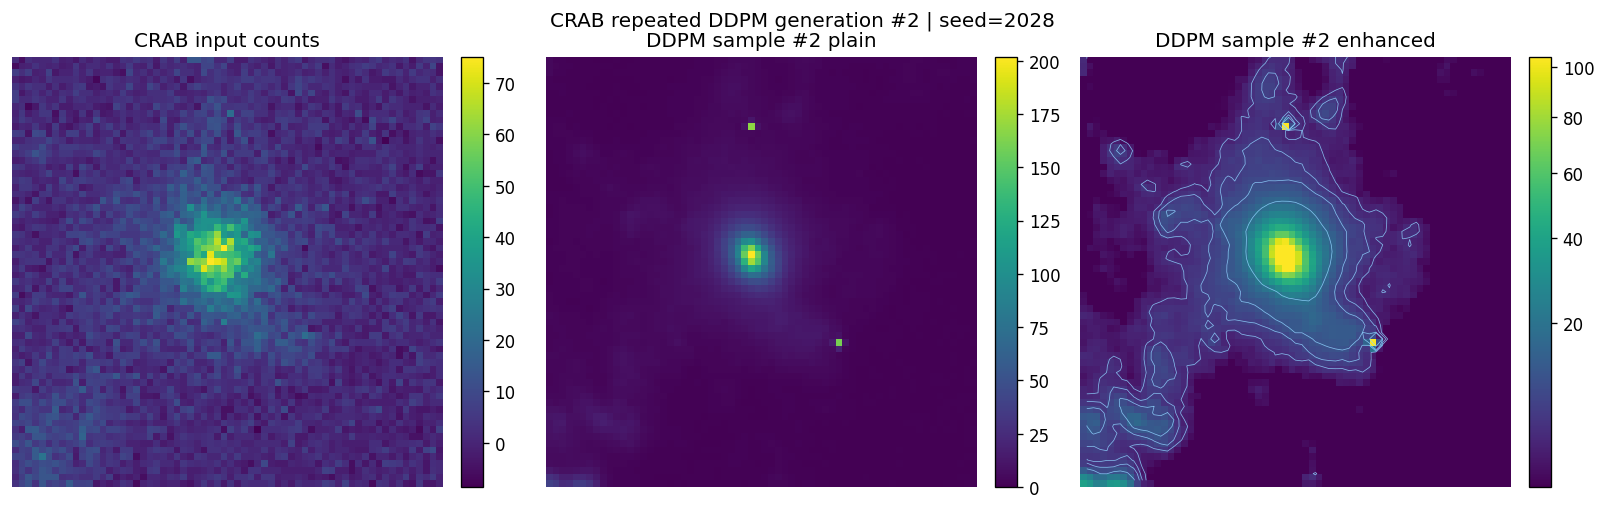

Sampling: 100%|██████████| 2000/2000 [00:03<00:00, 639.64it/s]


Saved sample figure: /root/LHAI_KM2A/saves/PREDICT/DDPM/CRAB/sample_003__SS433_64_KM2AE25__Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.png


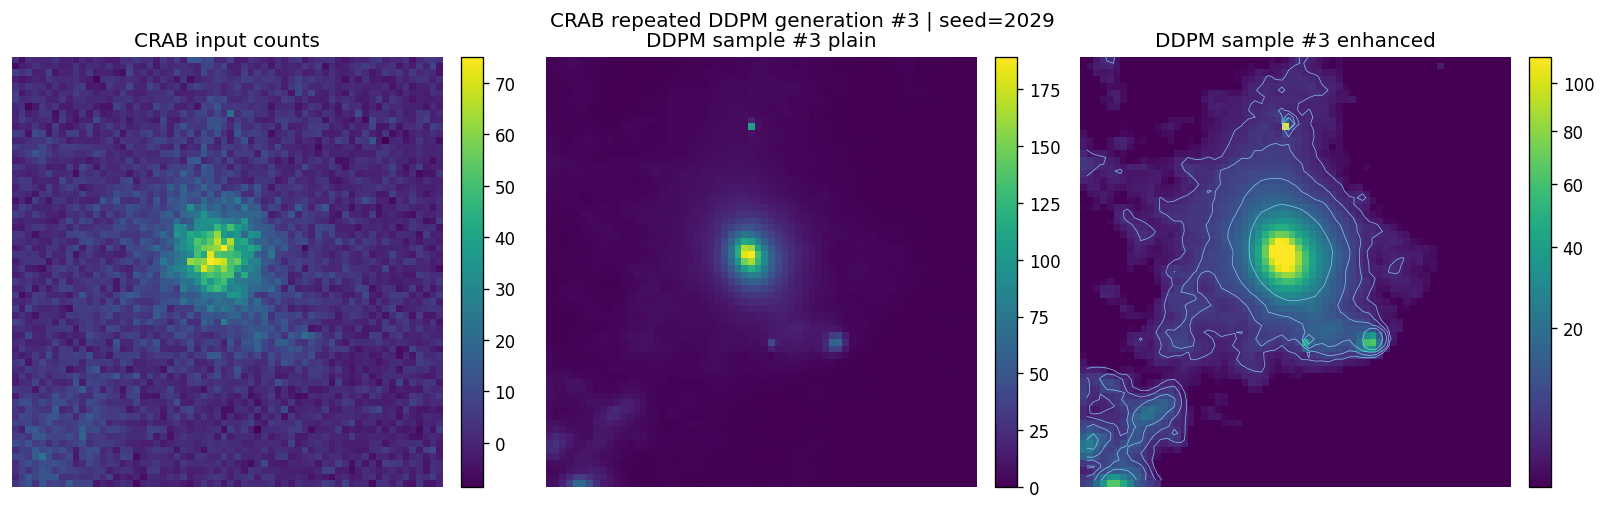

Sampling: 100%|██████████| 2000/2000 [00:03<00:00, 646.79it/s]


Saved sample figure: /root/LHAI_KM2A/saves/PREDICT/DDPM/CRAB/sample_004__SS433_64_KM2AE25__Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.png


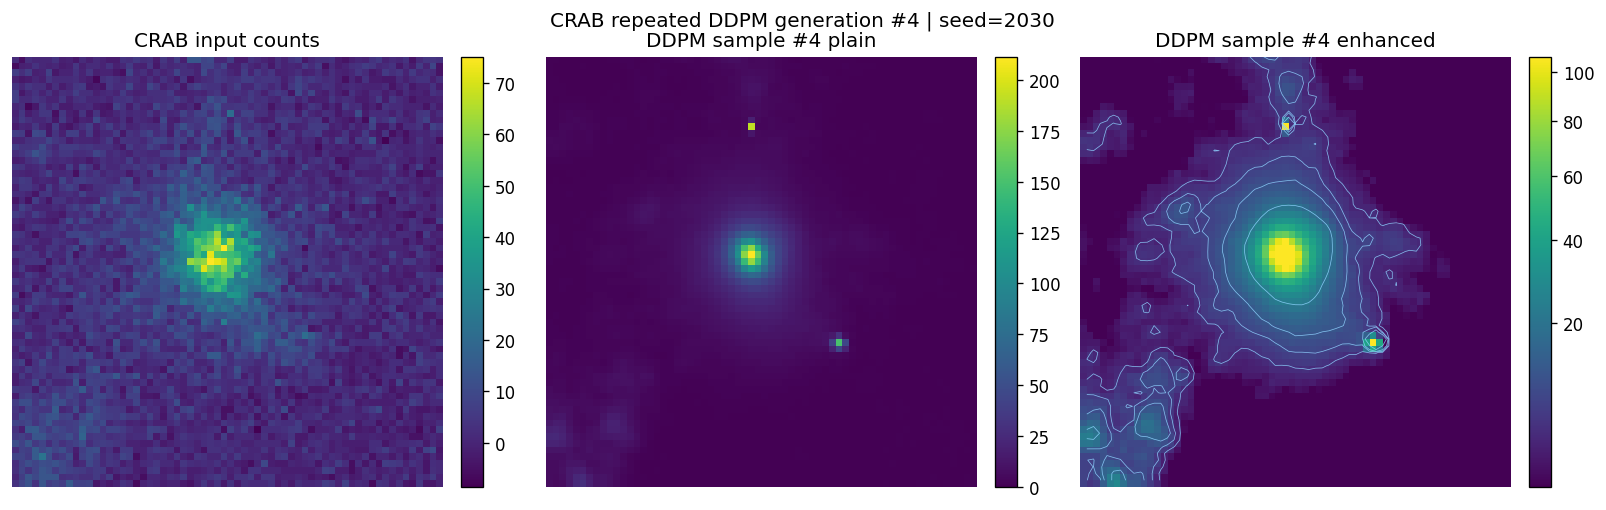

Sampling: 100%|██████████| 2000/2000 [00:03<00:00, 646.14it/s]


Saved sample figure: /root/LHAI_KM2A/saves/PREDICT/DDPM/CRAB/sample_005__SS433_64_KM2AE25__Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.png


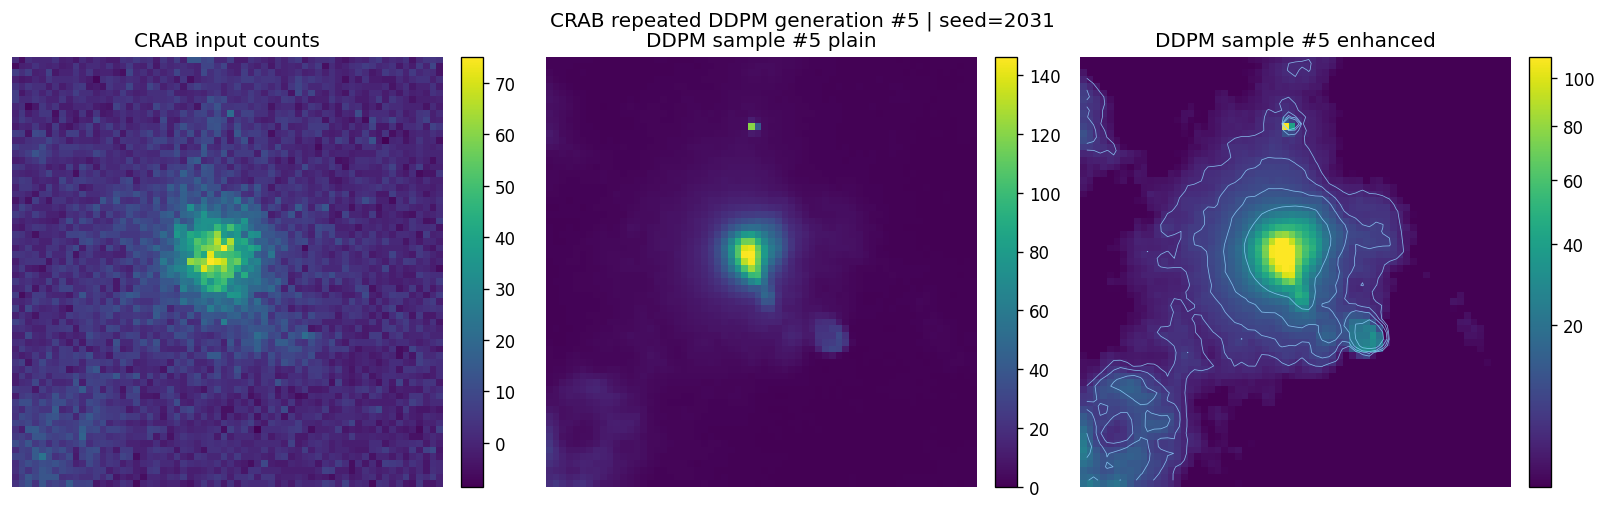

Sampling: 100%|██████████| 2000/2000 [00:03<00:00, 644.93it/s]


Saved sample figure: /root/LHAI_KM2A/saves/PREDICT/DDPM/CRAB/sample_006__SS433_64_KM2AE25__Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.png


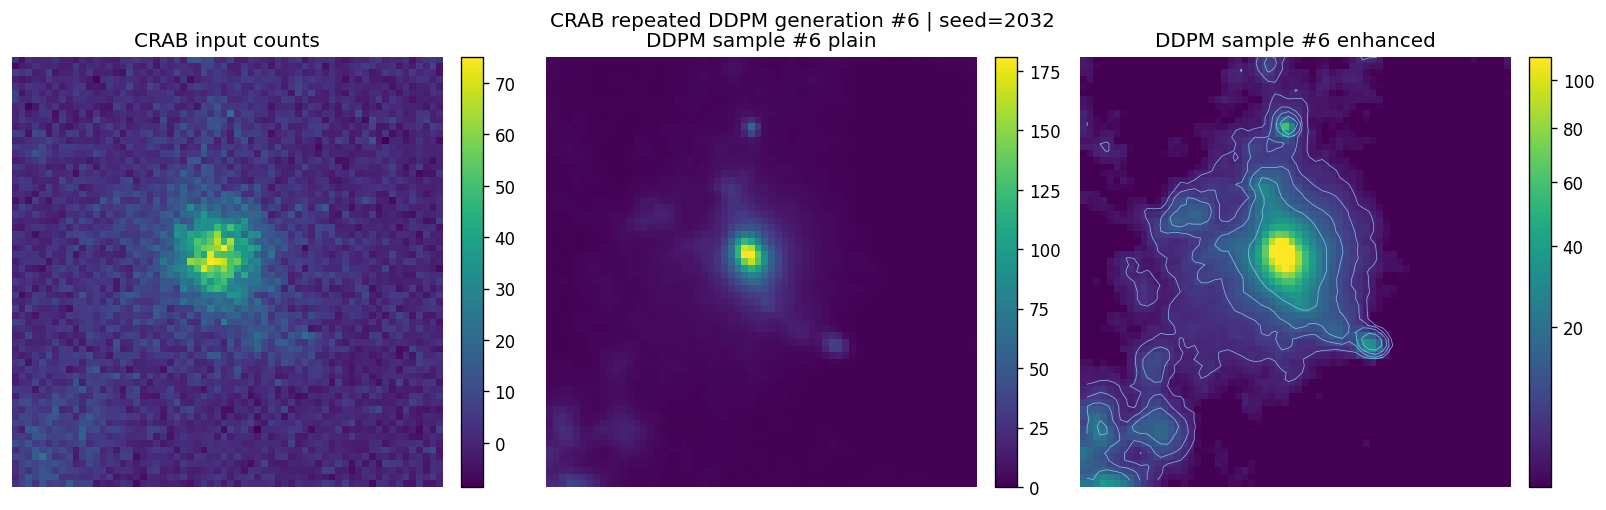

Sampling: 100%|██████████| 2000/2000 [00:03<00:00, 650.92it/s]


Saved sample figure: /root/LHAI_KM2A/saves/PREDICT/DDPM/CRAB/sample_007__SS433_64_KM2AE25__Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.png


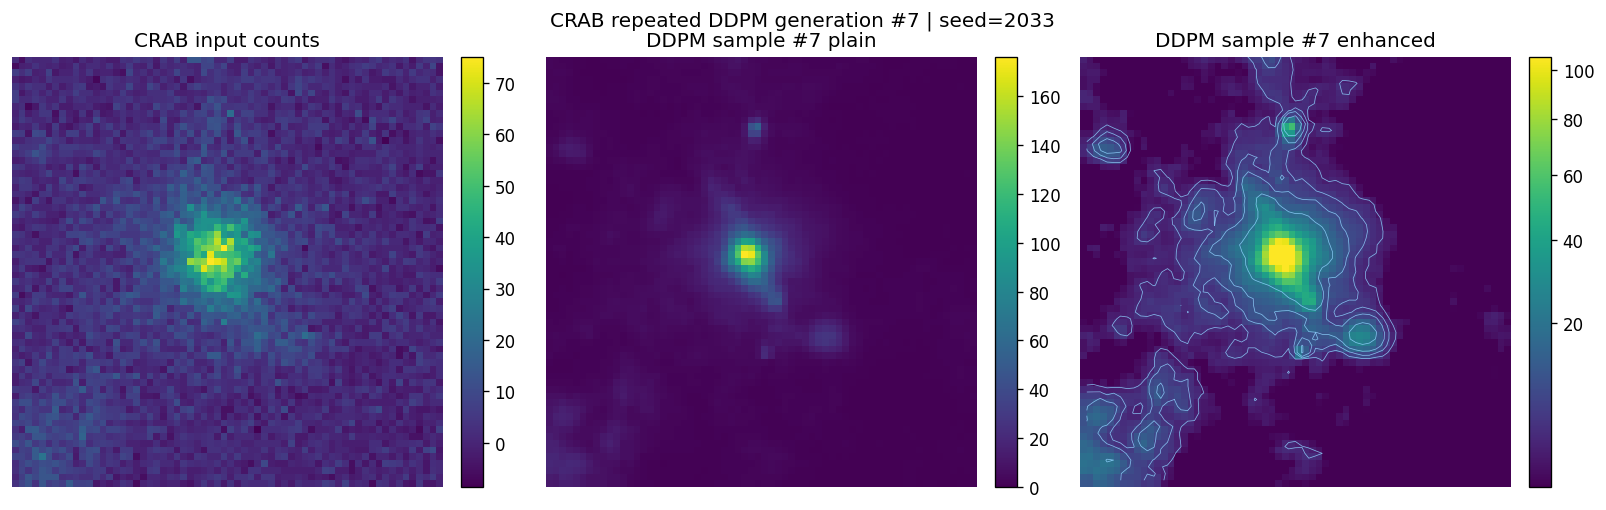

Sampling: 100%|██████████| 2000/2000 [00:03<00:00, 651.96it/s]


Saved sample figure: /root/LHAI_KM2A/saves/PREDICT/DDPM/CRAB/sample_008__SS433_64_KM2AE25__Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.png


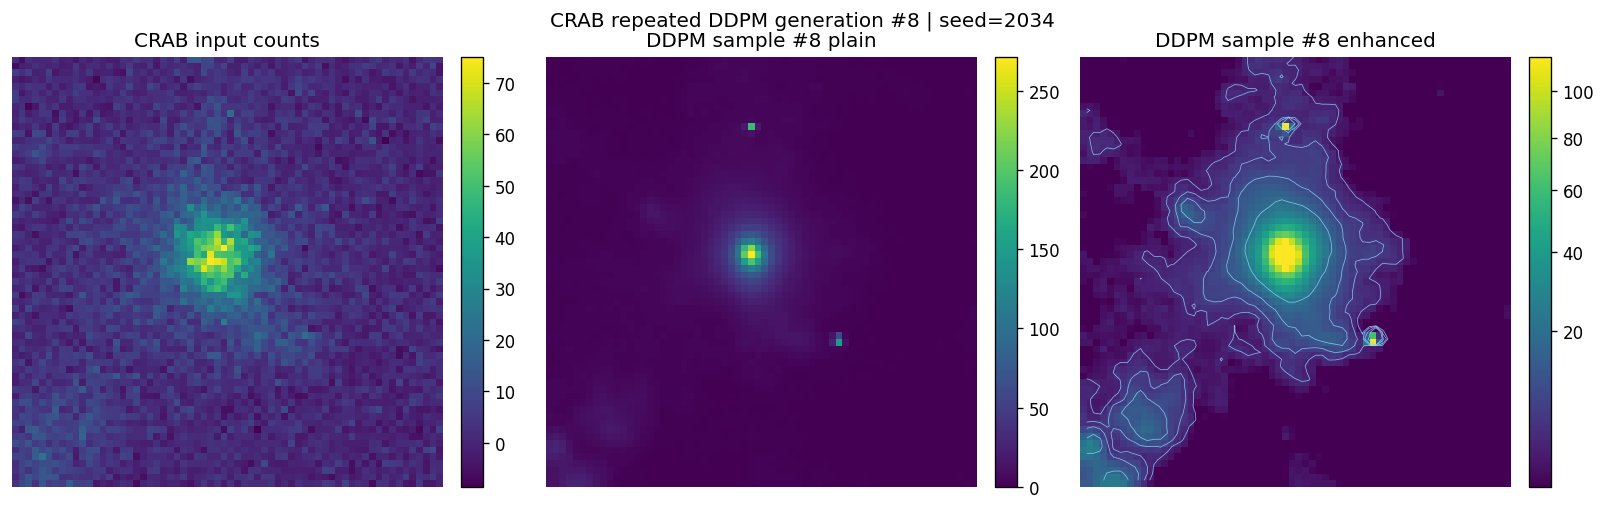

Sampling: 100%|██████████| 2000/2000 [00:03<00:00, 653.96it/s]


Saved sample figure: /root/LHAI_KM2A/saves/PREDICT/DDPM/CRAB/sample_009__SS433_64_KM2AE25__Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.png


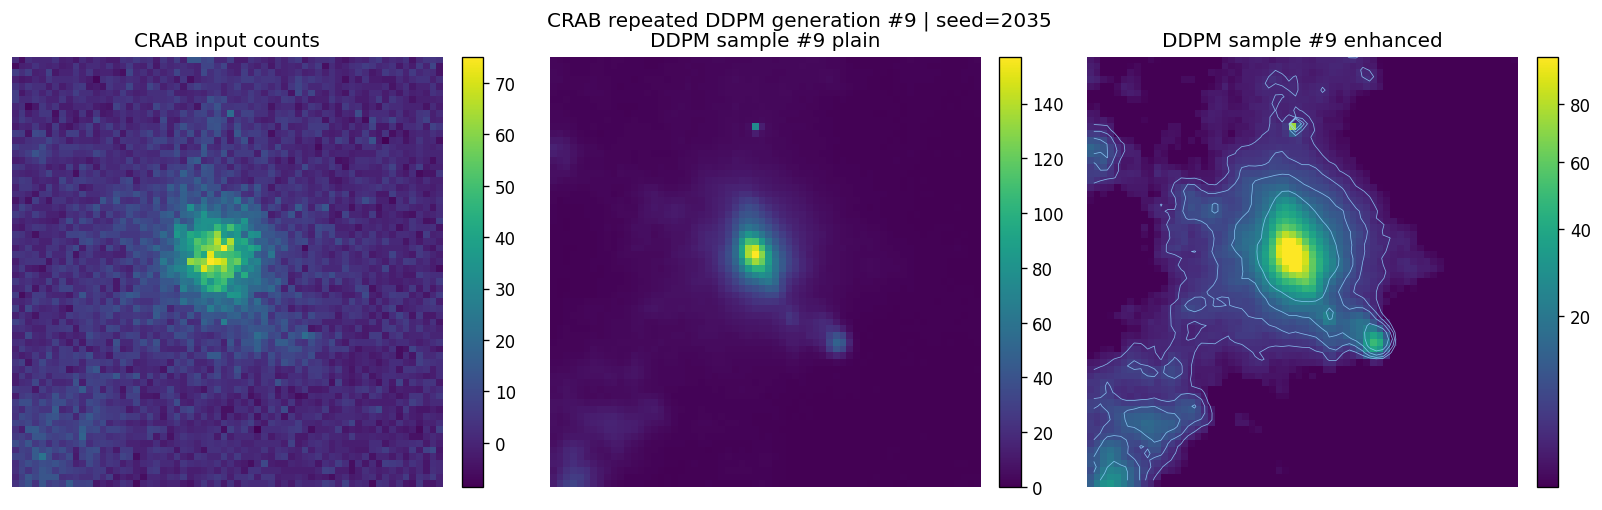

Sampling: 100%|██████████| 2000/2000 [00:03<00:00, 656.29it/s]


Saved sample figure: /root/LHAI_KM2A/saves/PREDICT/DDPM/CRAB/sample_010__SS433_64_KM2AE25__Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.png


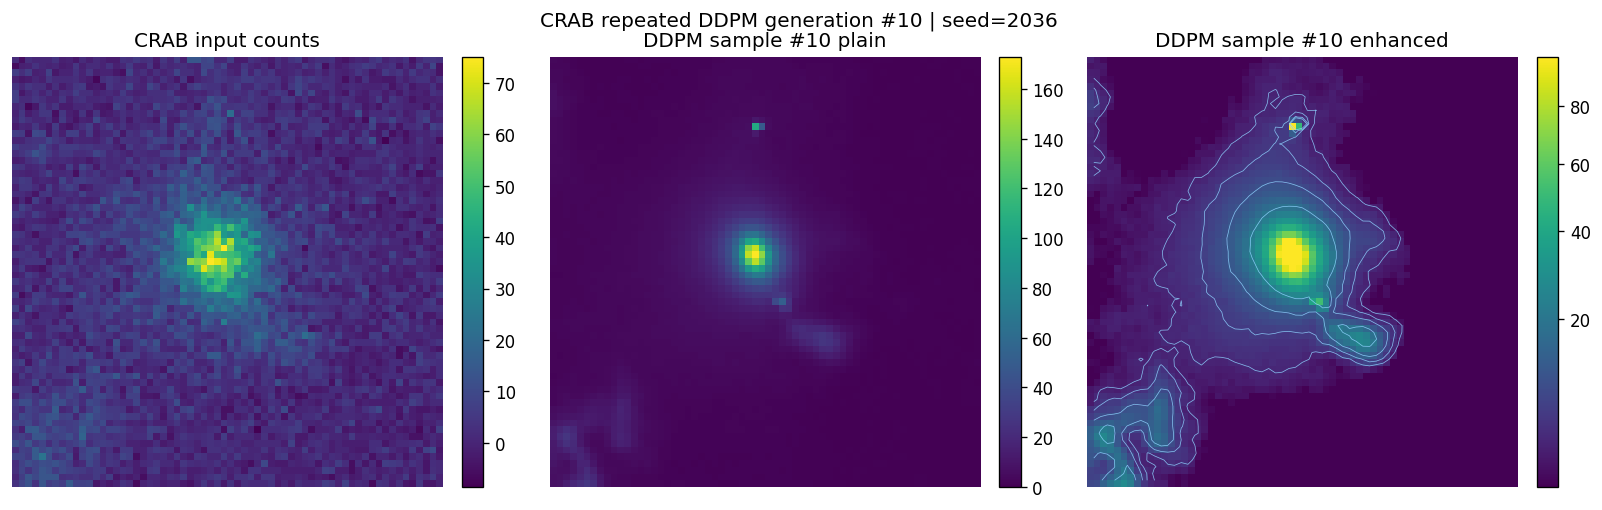

Sampling: 100%|██████████| 2000/2000 [00:03<00:00, 647.37it/s]


Saved sample figure: /root/LHAI_KM2A/saves/PREDICT/DDPM/CRAB/sample_011__SS433_64_KM2AE25__Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.png


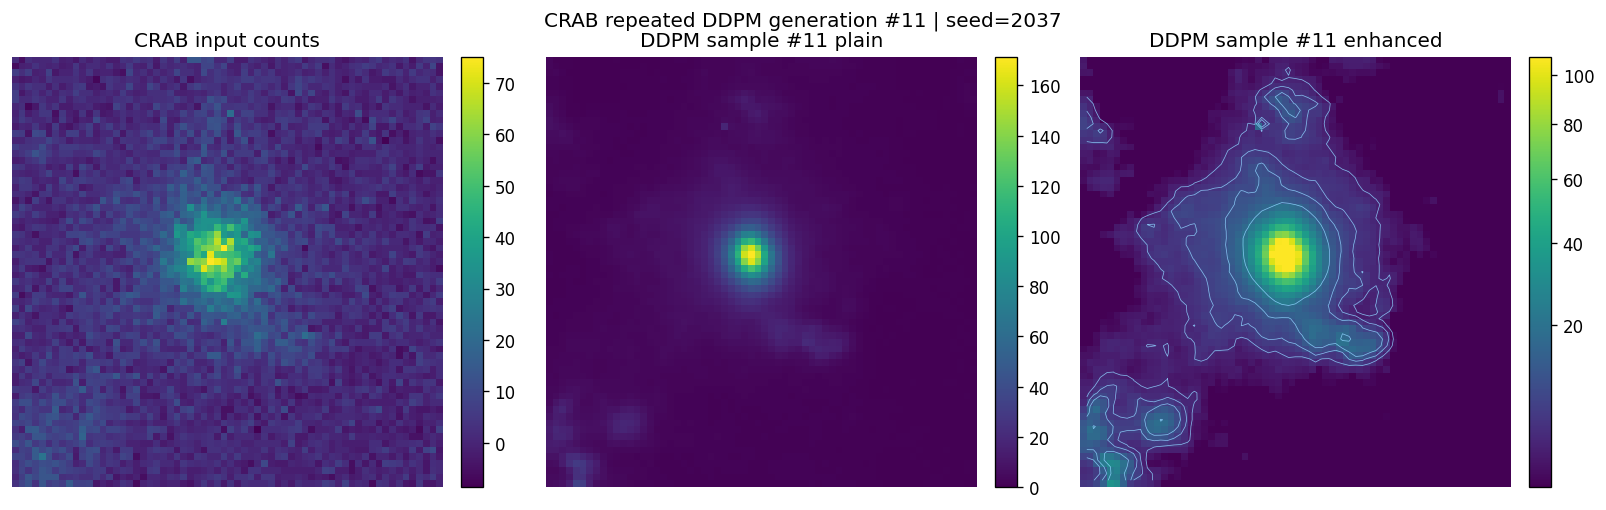

Sampling: 100%|██████████| 2000/2000 [00:03<00:00, 658.16it/s]


Saved sample figure: /root/LHAI_KM2A/saves/PREDICT/DDPM/CRAB/sample_012__SS433_64_KM2AE25__Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.png


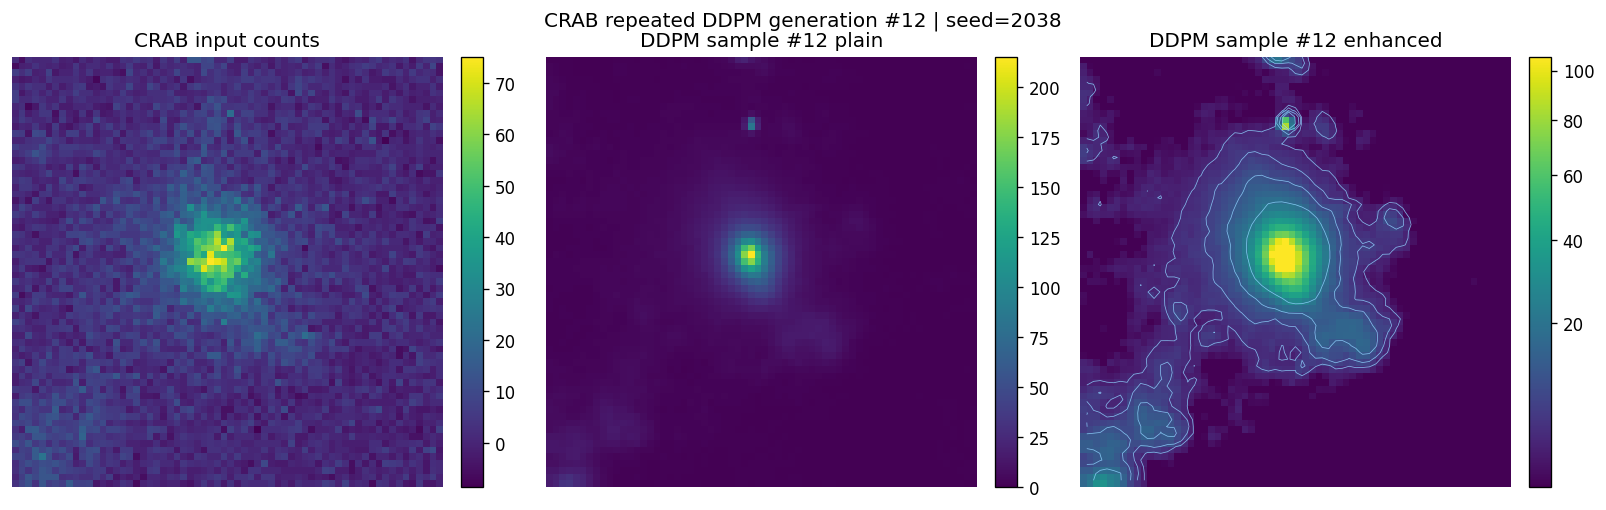

Sampling: 100%|██████████| 2000/2000 [00:02<00:00, 668.29it/s]


Saved sample figure: /root/LHAI_KM2A/saves/PREDICT/DDPM/CRAB/sample_013__SS433_64_KM2AE25__Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.png


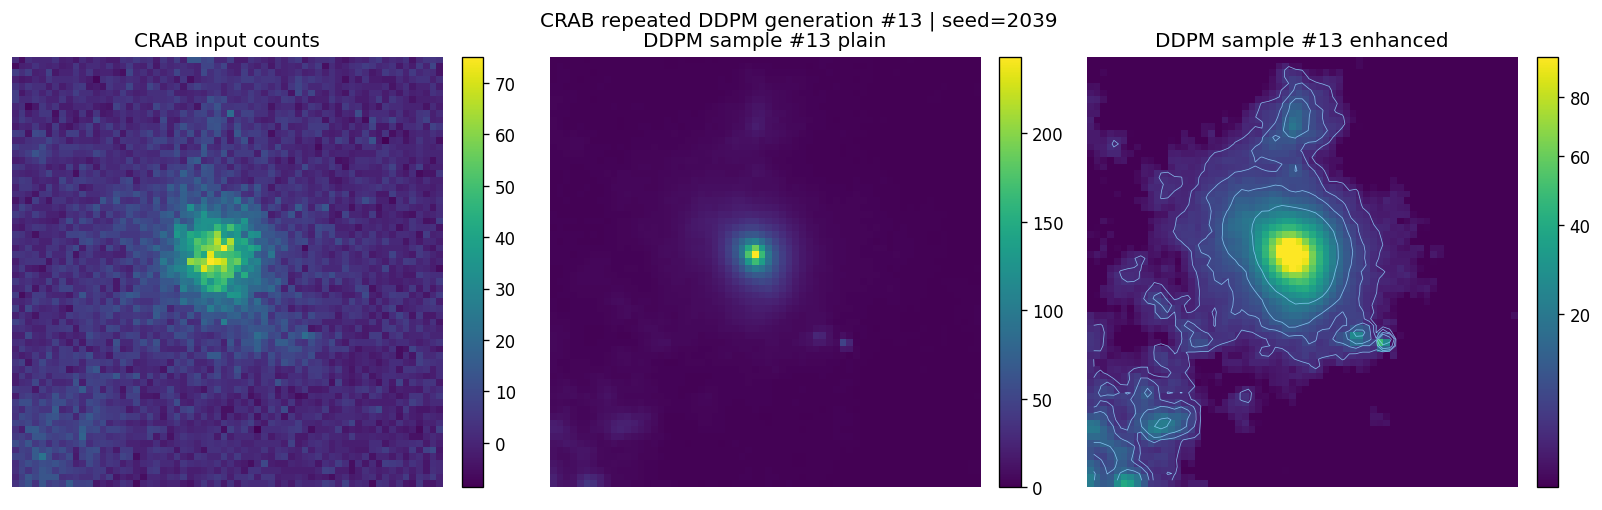

Sampling: 100%|██████████| 2000/2000 [00:03<00:00, 664.75it/s]


Saved sample figure: /root/LHAI_KM2A/saves/PREDICT/DDPM/CRAB/sample_014__SS433_64_KM2AE25__Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.png


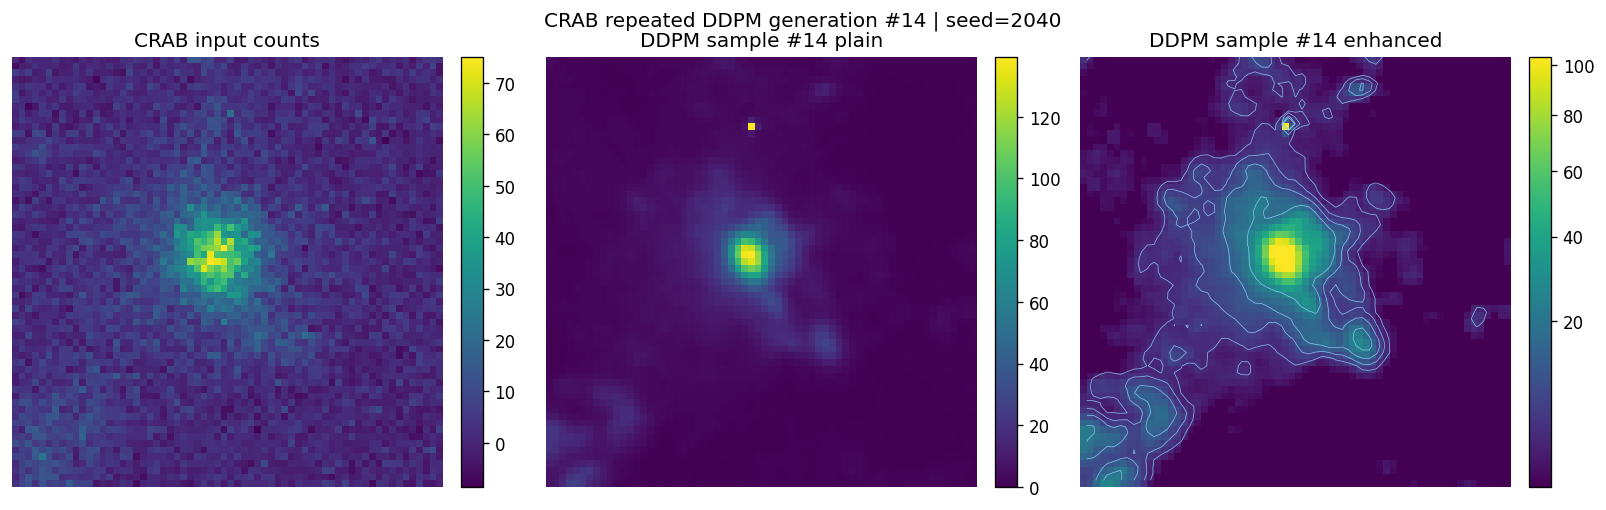

Sampling: 100%|██████████| 2000/2000 [00:03<00:00, 664.63it/s]


Saved sample figure: /root/LHAI_KM2A/saves/PREDICT/DDPM/CRAB/sample_015__SS433_64_KM2AE25__Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.png


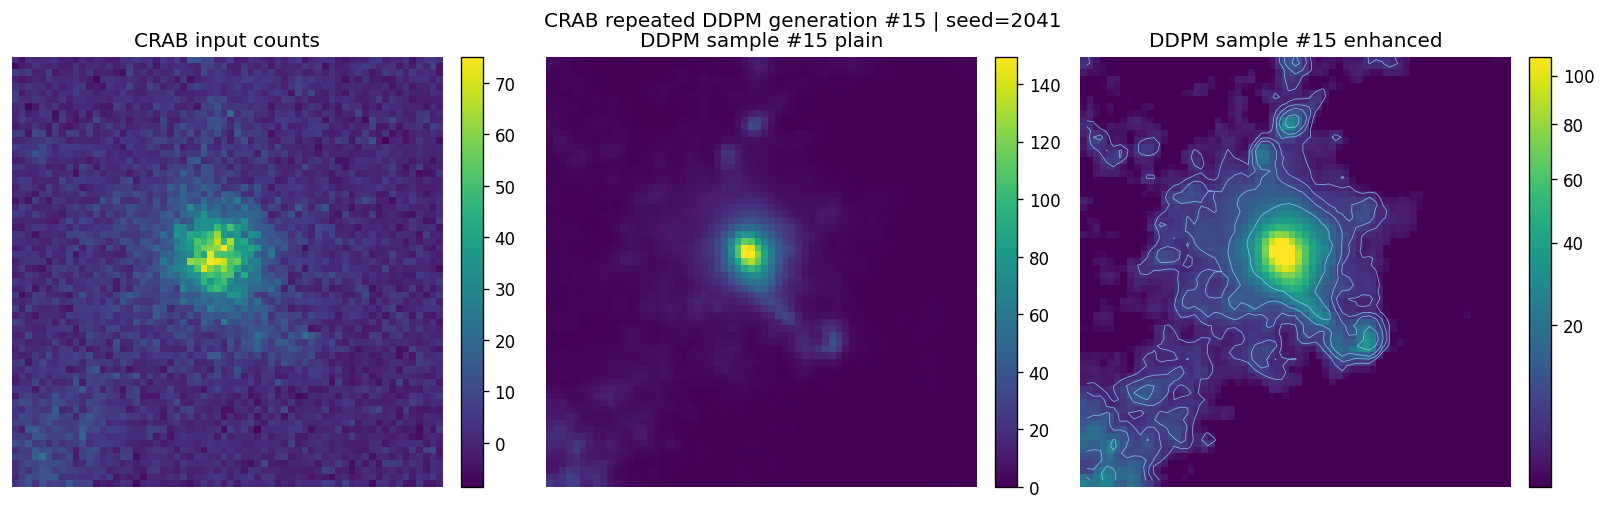

Sampling: 100%|██████████| 2000/2000 [00:03<00:00, 658.58it/s]


Saved sample figure: /root/LHAI_KM2A/saves/PREDICT/DDPM/CRAB/sample_016__SS433_64_KM2AE25__Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.png


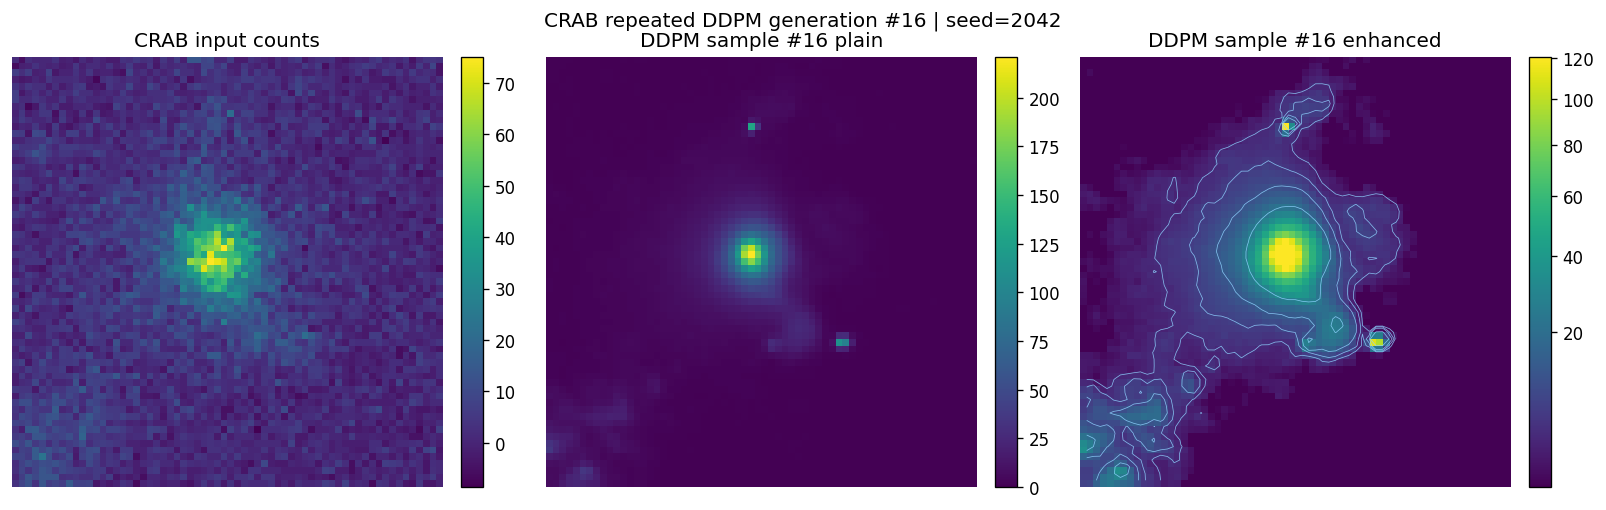

Sampling: 100%|██████████| 2000/2000 [00:03<00:00, 633.76it/s]


Saved sample figure: /root/LHAI_KM2A/saves/PREDICT/DDPM/CRAB/sample_017__SS433_64_KM2AE25__Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.png


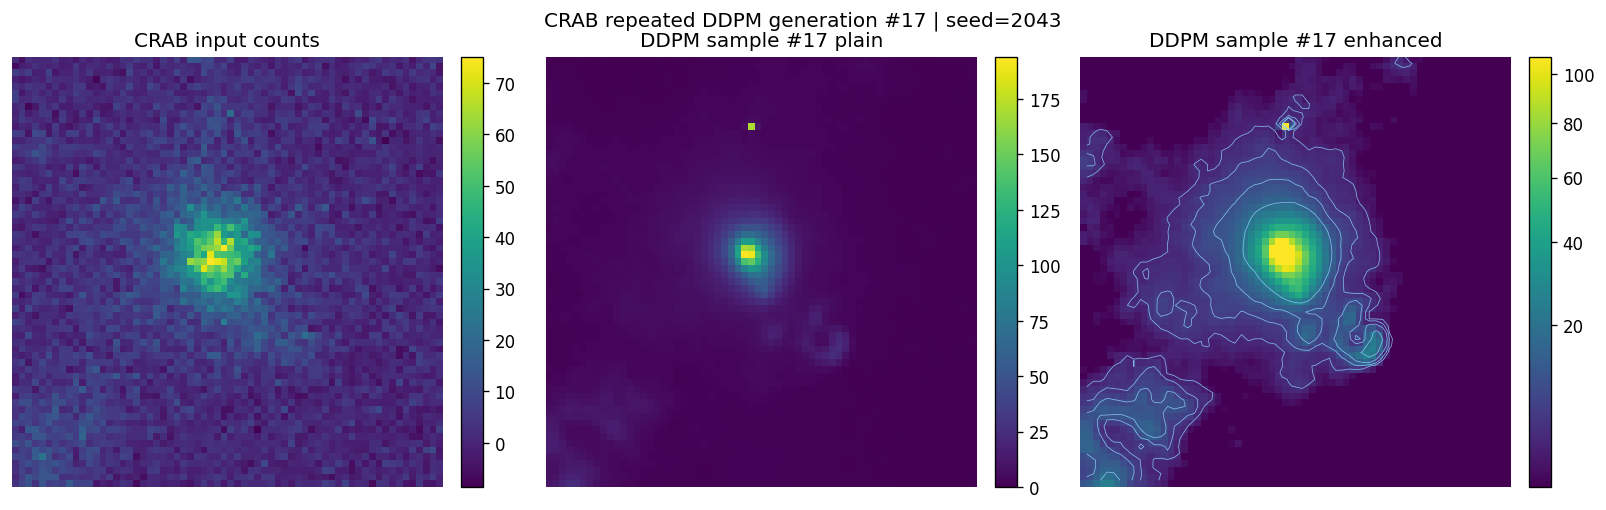

Sampling: 100%|██████████| 2000/2000 [00:03<00:00, 660.16it/s]


Saved sample figure: /root/LHAI_KM2A/saves/PREDICT/DDPM/CRAB/sample_018__SS433_64_KM2AE25__Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.png


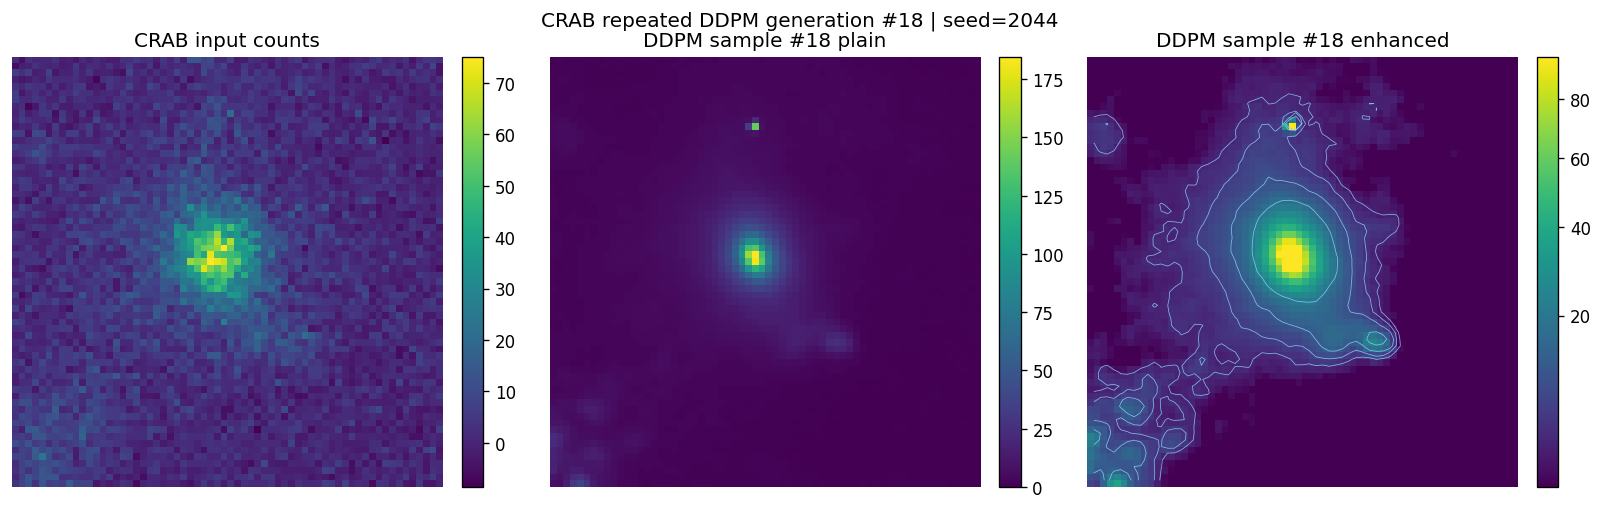

Sampling: 100%|██████████| 2000/2000 [00:03<00:00, 657.99it/s]


Saved sample figure: /root/LHAI_KM2A/saves/PREDICT/DDPM/CRAB/sample_019__SS433_64_KM2AE25__Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.png


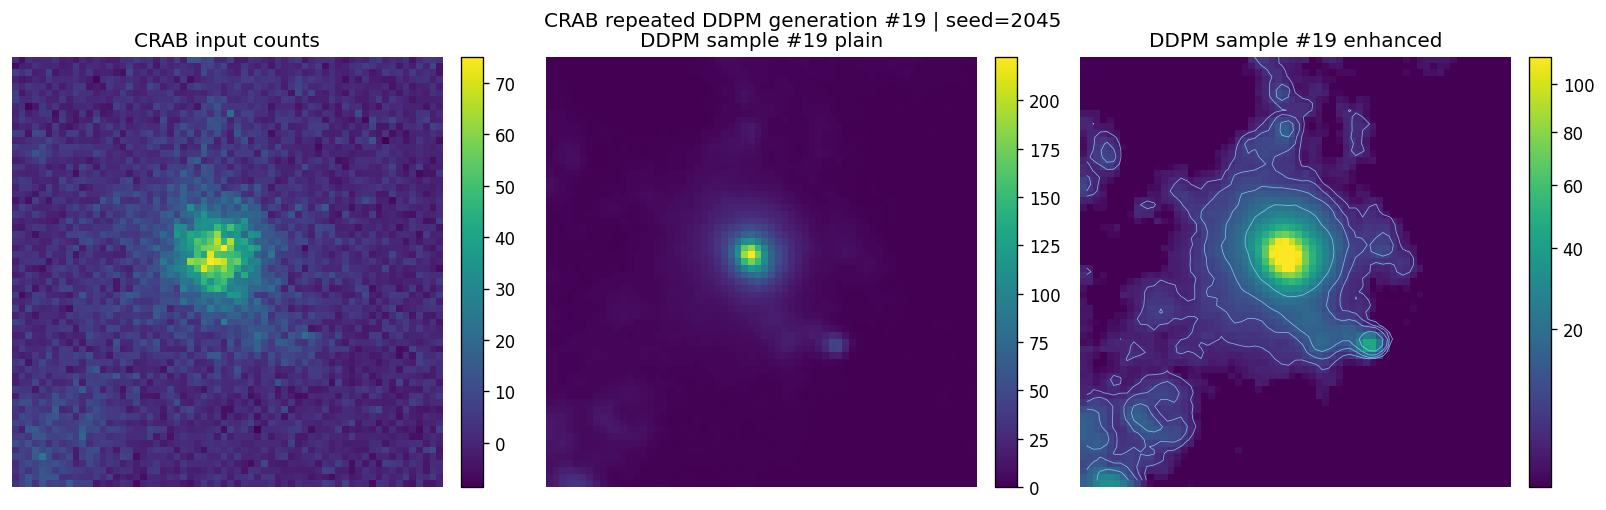

Repeated CRAB DDPM samples: 100%|██████████| 20/20 [01:13<00:00,  3.69s/it]

samples_norm shape: (20, 64, 64)
samples_counts shape: (20, 64, 64)
mean counts range=(0.2673, 191.6), std range=(0.1801, 61.3)


In [6]:
def reduce_generated(generated):
    if generated.dim() == 5:
        if generated.shape[0] == 1:
            generated = generated[:, -1]
        else:
            generated = generated[-1]
    if CLAMP_OUTPUT:
        generated = generated.clamp(-1.0, 1.0) if DATA_RANGE == 2.0 else generated.clamp(0.0, 1.0)
    return generated


def sample_ddpm_once(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    with torch.no_grad():
        generated = diffusion.reverse_diffusion(
            model=unet,
            n_images=1,
            n_channels=1,
            input_image=condition_tensor,
            save_time_steps=None,
        )
    return reduce_generated(generated).detach().cpu().numpy()[0, 0].astype(np.float32)


def get_display_limits(image, floor_percentile=50, ceil_percentile=99.7):
    positive = image[np.isfinite(image) & (image > 0)]
    if positive.size == 0:
        finite = image[np.isfinite(image)]
        if finite.size == 0:
            return 0.0, 1.0
        return float(np.nanmin(finite)), float(np.nanmax(finite) + 1e-6)
    vmin = float(np.percentile(positive, floor_percentile))
    vmax = float(np.percentile(positive, ceil_percentile))
    if vmax <= vmin:
        vmax = float(positive.max())
    if vmax <= vmin:
        vmax = vmin + 1e-6
    return vmin, vmax


def contour_levels(image, percentiles=CONTOUR_PERCENTILES):
    positive = image[np.isfinite(image) & (image > 0)]
    if positive.size == 0:
        return []
    levels = np.percentile(positive, percentiles)
    levels = np.unique(levels[levels > 0])
    return levels if levels.size >= 2 else []


def imshow_counts(ax, image, title, cmap=VIS_CMAP_IMAGE, enhanced=False, add_contour=None):
    if enhanced:
        vmin, vmax = get_display_limits(image)
        im = ax.imshow(image, origin="lower", cmap=cmap, norm=PowerNorm(gamma=0.55, vmin=vmin, vmax=vmax), interpolation="nearest")
    else:
        im = ax.imshow(image, origin="lower", cmap=cmap, interpolation="nearest")
    if add_contour is None:
        add_contour = bool(enhanced)
    if add_contour:
        levels = contour_levels(image)
        if len(levels) > 0:
            ax.contour(image, levels=levels, origin="lower", colors="#8fd3ff", linewidths=0.45, alpha=0.85)
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return im


samples_norm = []
samples_counts = []
for sample_i in tqdm(range(N_SAMPLES), desc="Repeated CRAB DDPM samples"):
    sample_norm = sample_ddpm_once(BASE_SEED + sample_i)
    sample_counts = restore_norm_to_counts(sample_norm).astype(np.float32)
    samples_norm.append(sample_norm)
    samples_counts.append(sample_counts)

    if SAVE_EACH_SAMPLE_FIGURE:
        fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
        imshow_counts(axes[0], input_counts_resized, "CRAB input counts", enhanced=False)
        imshow_counts(axes[1], sample_counts, f"DDPM sample #{sample_i} plain", enhanced=False)
        imshow_counts(axes[2], sample_counts, f"DDPM sample #{sample_i} enhanced", enhanced=True)
        fig.suptitle(f"CRAB repeated DDPM generation #{sample_i} | seed={BASE_SEED + sample_i}")
        fig.tight_layout()
        if SAVE_OUTPUTS:
            OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
            fig_path = OUTPUT_DIR / f"sample_{sample_i:03d}__{crab_path.stem}__{model_weight_path.stem}.png"
            fig.savefig(fig_path, dpi=300, bbox_inches="tight")
            print(f"Saved sample figure: {fig_path}")
        plt.show()

samples_norm = np.stack(samples_norm).astype(np.float32)
samples_counts = np.stack(samples_counts).astype(np.float32)
mean_norm = samples_norm.mean(axis=0)
std_norm = samples_norm.std(axis=0, ddof=1 if N_SAMPLES > 1 else 0)
mean_counts = samples_counts.mean(axis=0)
std_counts = samples_counts.std(axis=0, ddof=1 if N_SAMPLES > 1 else 0)

print(f"samples_norm shape: {samples_norm.shape}")
print(f"samples_counts shape: {samples_counts.shape}")
print(f"mean counts range=({mean_counts.min():.4g}, {mean_counts.max():.4g}), std range=({std_counts.min():.4g}, {std_counts.max():.4g})")


Saved uncertainty map: /root/LHAI_KM2A/saves/PREDICT/DDPM/CRAB/uncertainty_maps__SS433_64_KM2AE25__Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.png


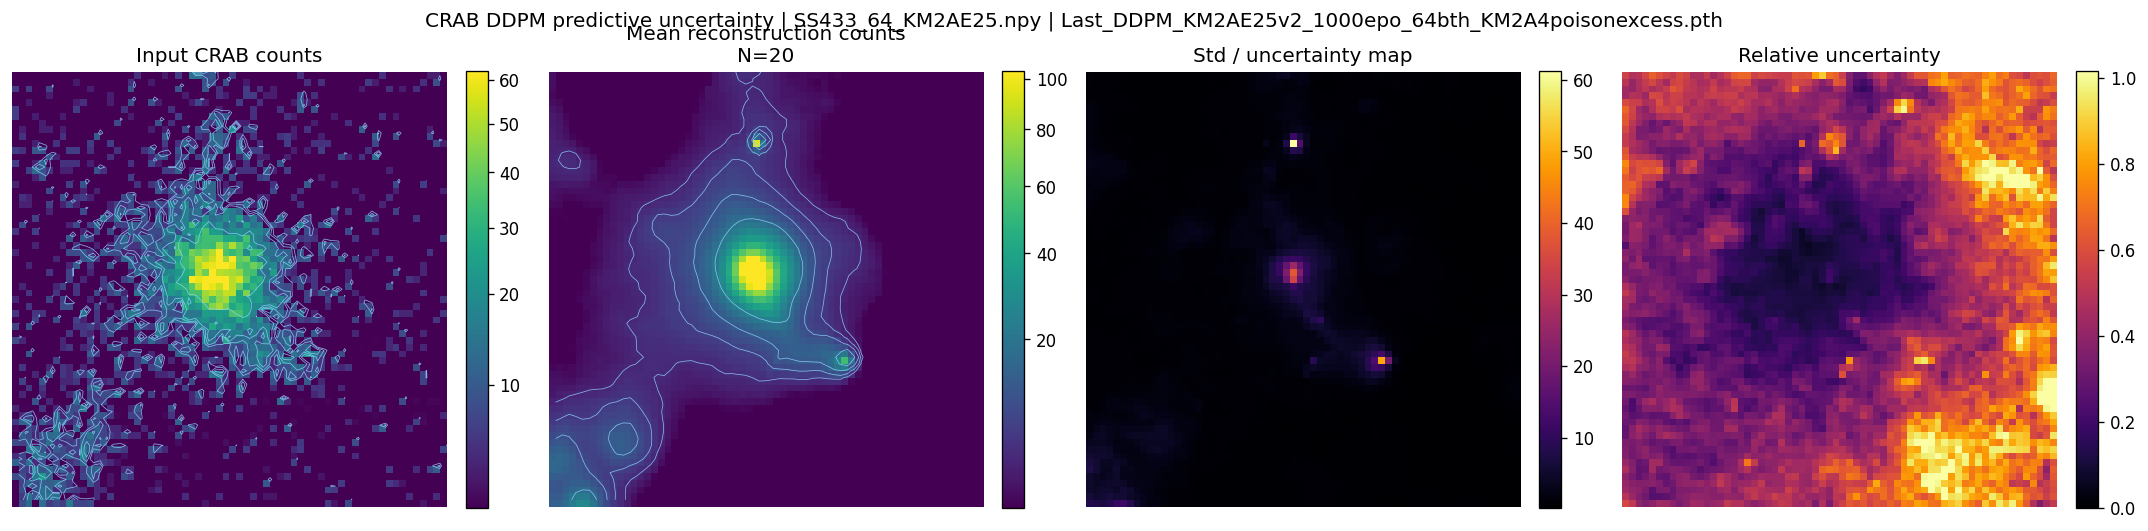

In [7]:
relative_std = std_counts / np.maximum(np.abs(mean_counts), EPS_COUNTS)
fig, axes = plt.subplots(1, 4, figsize=(18, 4.4))
imshow_counts(axes[0], input_counts_resized, "Input CRAB counts", enhanced=True)
imshow_counts(axes[1], mean_counts, f"Mean reconstruction counts\nN={N_SAMPLES}", enhanced=True)
im = axes[2].imshow(std_counts, origin="lower", cmap=VIS_CMAP_UNCERTAINTY, interpolation="nearest")
axes[2].set_title("Std / uncertainty map")
axes[2].axis("off")
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
im = axes[3].imshow(relative_std, origin="lower", cmap=VIS_CMAP_UNCERTAINTY, interpolation="nearest", vmin=0, vmax=np.nanpercentile(relative_std, 99))
axes[3].set_title("Relative uncertainty")
axes[3].axis("off")
plt.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)
fig.suptitle(f"CRAB DDPM predictive uncertainty | {crab_path.name} | {model_weight_path.name}")
fig.tight_layout()
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig_path = OUTPUT_DIR / f"uncertainty_maps__{crab_path.stem}__{model_weight_path.stem}.png"
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    print(f"Saved uncertainty map: {fig_path}")
plt.show()


## 5. Manually selected reverse-process snapshots

Set `CUSTOM_SNAPSHOT_STEPS` in the config cell. The values are DDPM timesteps, where larger timesteps are noisier and `0` is the final reconstruction.


In [8]:
def snapshot_steps_from_config(noise_steps, custom_steps):
    if custom_steps is None:
        custom_steps = [noise_steps - 1, int(0.75 * noise_steps), int(0.5 * noise_steps), int(0.25 * noise_steps), 0]
    steps = np.unique(np.clip(np.asarray(custom_steps, dtype=int), 0, noise_steps - 1))[::-1]
    if steps[-1] != 0:
        steps = np.r_[steps, 0]
    return [int(step) for step in steps]


snapshot_steps = snapshot_steps_from_config(diffusion.noise_steps, CUSTOM_SNAPSHOT_STEPS)
print("Snapshot timesteps, high noise -> final:")
print(snapshot_steps)


@torch.no_grad()
def reverse_with_snapshots(model, diffusion, input_image, snapshot_steps, seed=0):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    model.eval()
    n_images = input_image.shape[0]
    device = diffusion.device
    x = torch.randn((n_images, 1, diffusion.img_size, diffusion.img_size), device=device)
    input_image = input_image.to(device)
    alpha = diffusion.alpha.to(device)
    alpha_bar = diffusion.alpha_bar.to(device)
    snapshot_set = set(snapshot_steps)
    snapshots = {}
    noise_predictions = {}
    flux_curve = []
    fwhm_curve = []
    for i in tqdm(reversed(range(0, diffusion.noise_steps)), desc="CRAB reverse trajectory", total=diffusion.noise_steps):
        t = torch.full((n_images,), i, dtype=torch.long, device=device)
        t_emb = diffusion._positional_encoding(t)
        xt_input = torch.cat([input_image, x], dim=1) if diffusion.conditional else x
        predicted_noise = model(xt_input, t_emb)
        alpha_t = alpha[t][:, None, None, None]
        alpha_bar_t = alpha_bar[t][:, None, None, None]
        noise = torch.randn_like(x) if i > 0 else torch.zeros_like(x)
        x = (1.0 / torch.sqrt(alpha_t)) * (x - ((1.0 - alpha_t) / torch.sqrt(1.0 - alpha_bar_t)) * predicted_noise) + torch.sqrt(1.0 - alpha_t) * noise
        x_np = x[0, 0].detach().cpu().numpy()
        x_counts = restore_norm_to_counts(x_np)
        flux_curve.append((i, image_flux(x_counts)))
        fwhm_curve.append((i, fwhm_from_image(x_counts, FWHM_CENTER_YX, FWHM_RADIAL_BIN_WIDTH)))
        if i in snapshot_set:
            snapshots[i] = x_np.copy()
            if SAVE_PREDICTED_NOISE:
                noise_predictions[i] = predicted_noise[0, 0].detach().cpu().numpy().copy()
    if 0 not in snapshots:
        snapshots[0] = x[0, 0].detach().cpu().numpy().copy()
        if SAVE_PREDICTED_NOISE:
            noise_predictions[0] = predicted_noise[0, 0].detach().cpu().numpy().copy()
    return snapshots, noise_predictions, np.asarray(flux_curve), np.asarray(fwhm_curve)


snapshots_norm, noise_predictions, flux_curve, fwhm_curve = reverse_with_snapshots(
    unet, diffusion, condition_tensor, snapshot_steps, seed=BASE_SEED + int(FINAL_SAMPLE_INDEX)
)
snapshots_counts = {t: restore_norm_to_counts(img).astype(np.float32) for t, img in snapshots_norm.items()}
trajectory_final_counts = snapshots_counts[min(snapshots_counts.keys())]
ordered_steps = sorted(snapshots_counts.keys(), reverse=True)
print(f"Captured {len(snapshots_counts)} snapshots and {len(noise_predictions)} predicted-noise maps.")


Snapshot timesteps, high noise -> final:
[1999, 100, 90, 80, 70, 60, 50, 40, 30, 20, 10, 5, 0]


CRAB reverse trajectory: 100%|██████████| 2000/2000 [00:04<00:00, 429.59it/s]

Captured 13 snapshots and 13 predicted-noise maps.


Saved trajectory snapshots: /root/LHAI_KM2A/saves/PREDICT/DDPM/CRAB/trajectory_snapshots__SS433_64_KM2AE25__sample0__Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.png


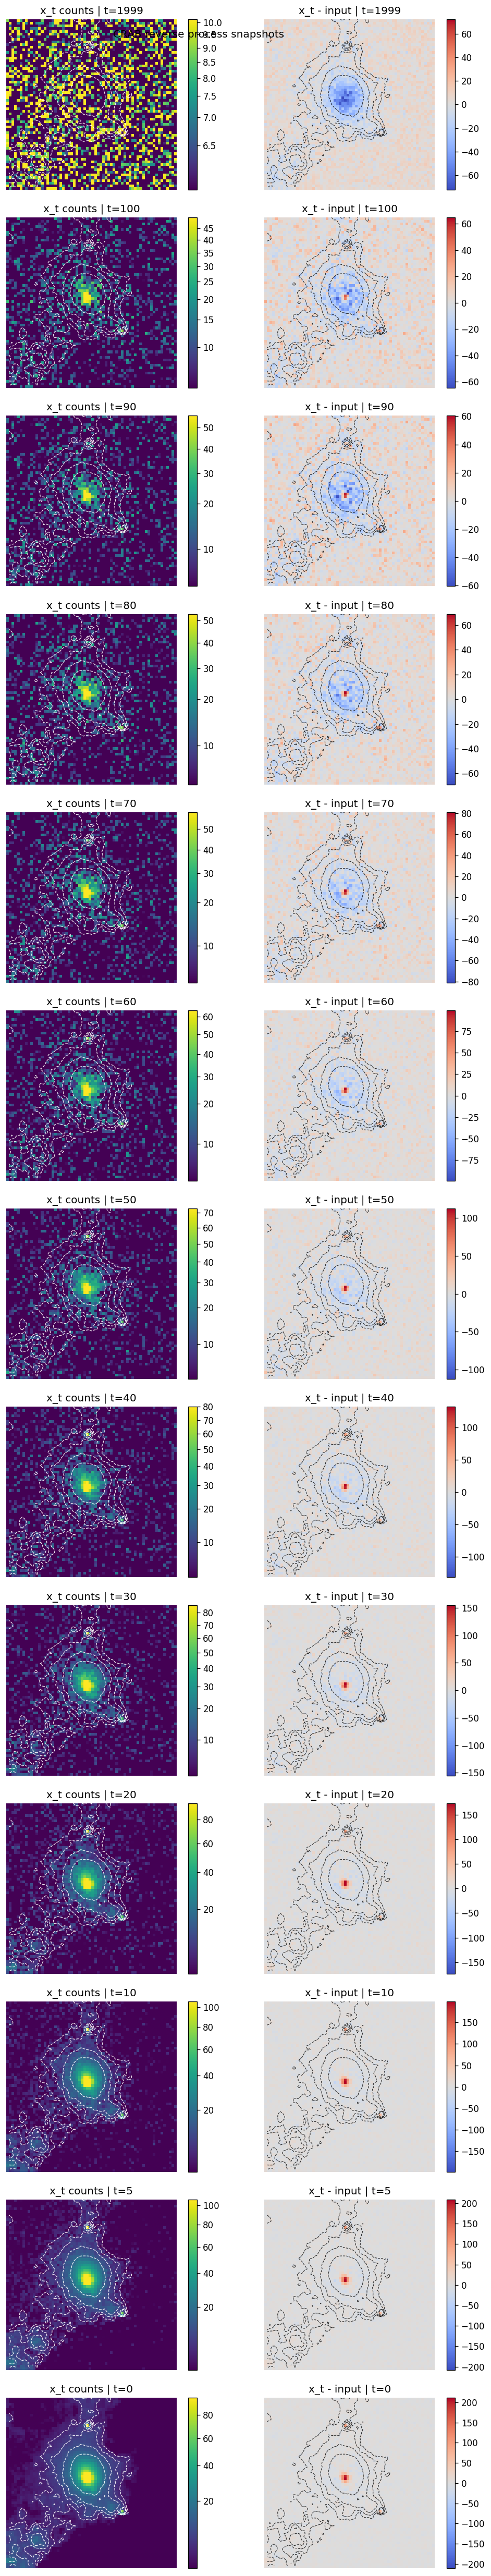

Saved predicted-noise figure: /root/LHAI_KM2A/saves/PREDICT/DDPM/CRAB/predicted_noise_quiver__SS433_64_KM2AE25__sample0__Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.png


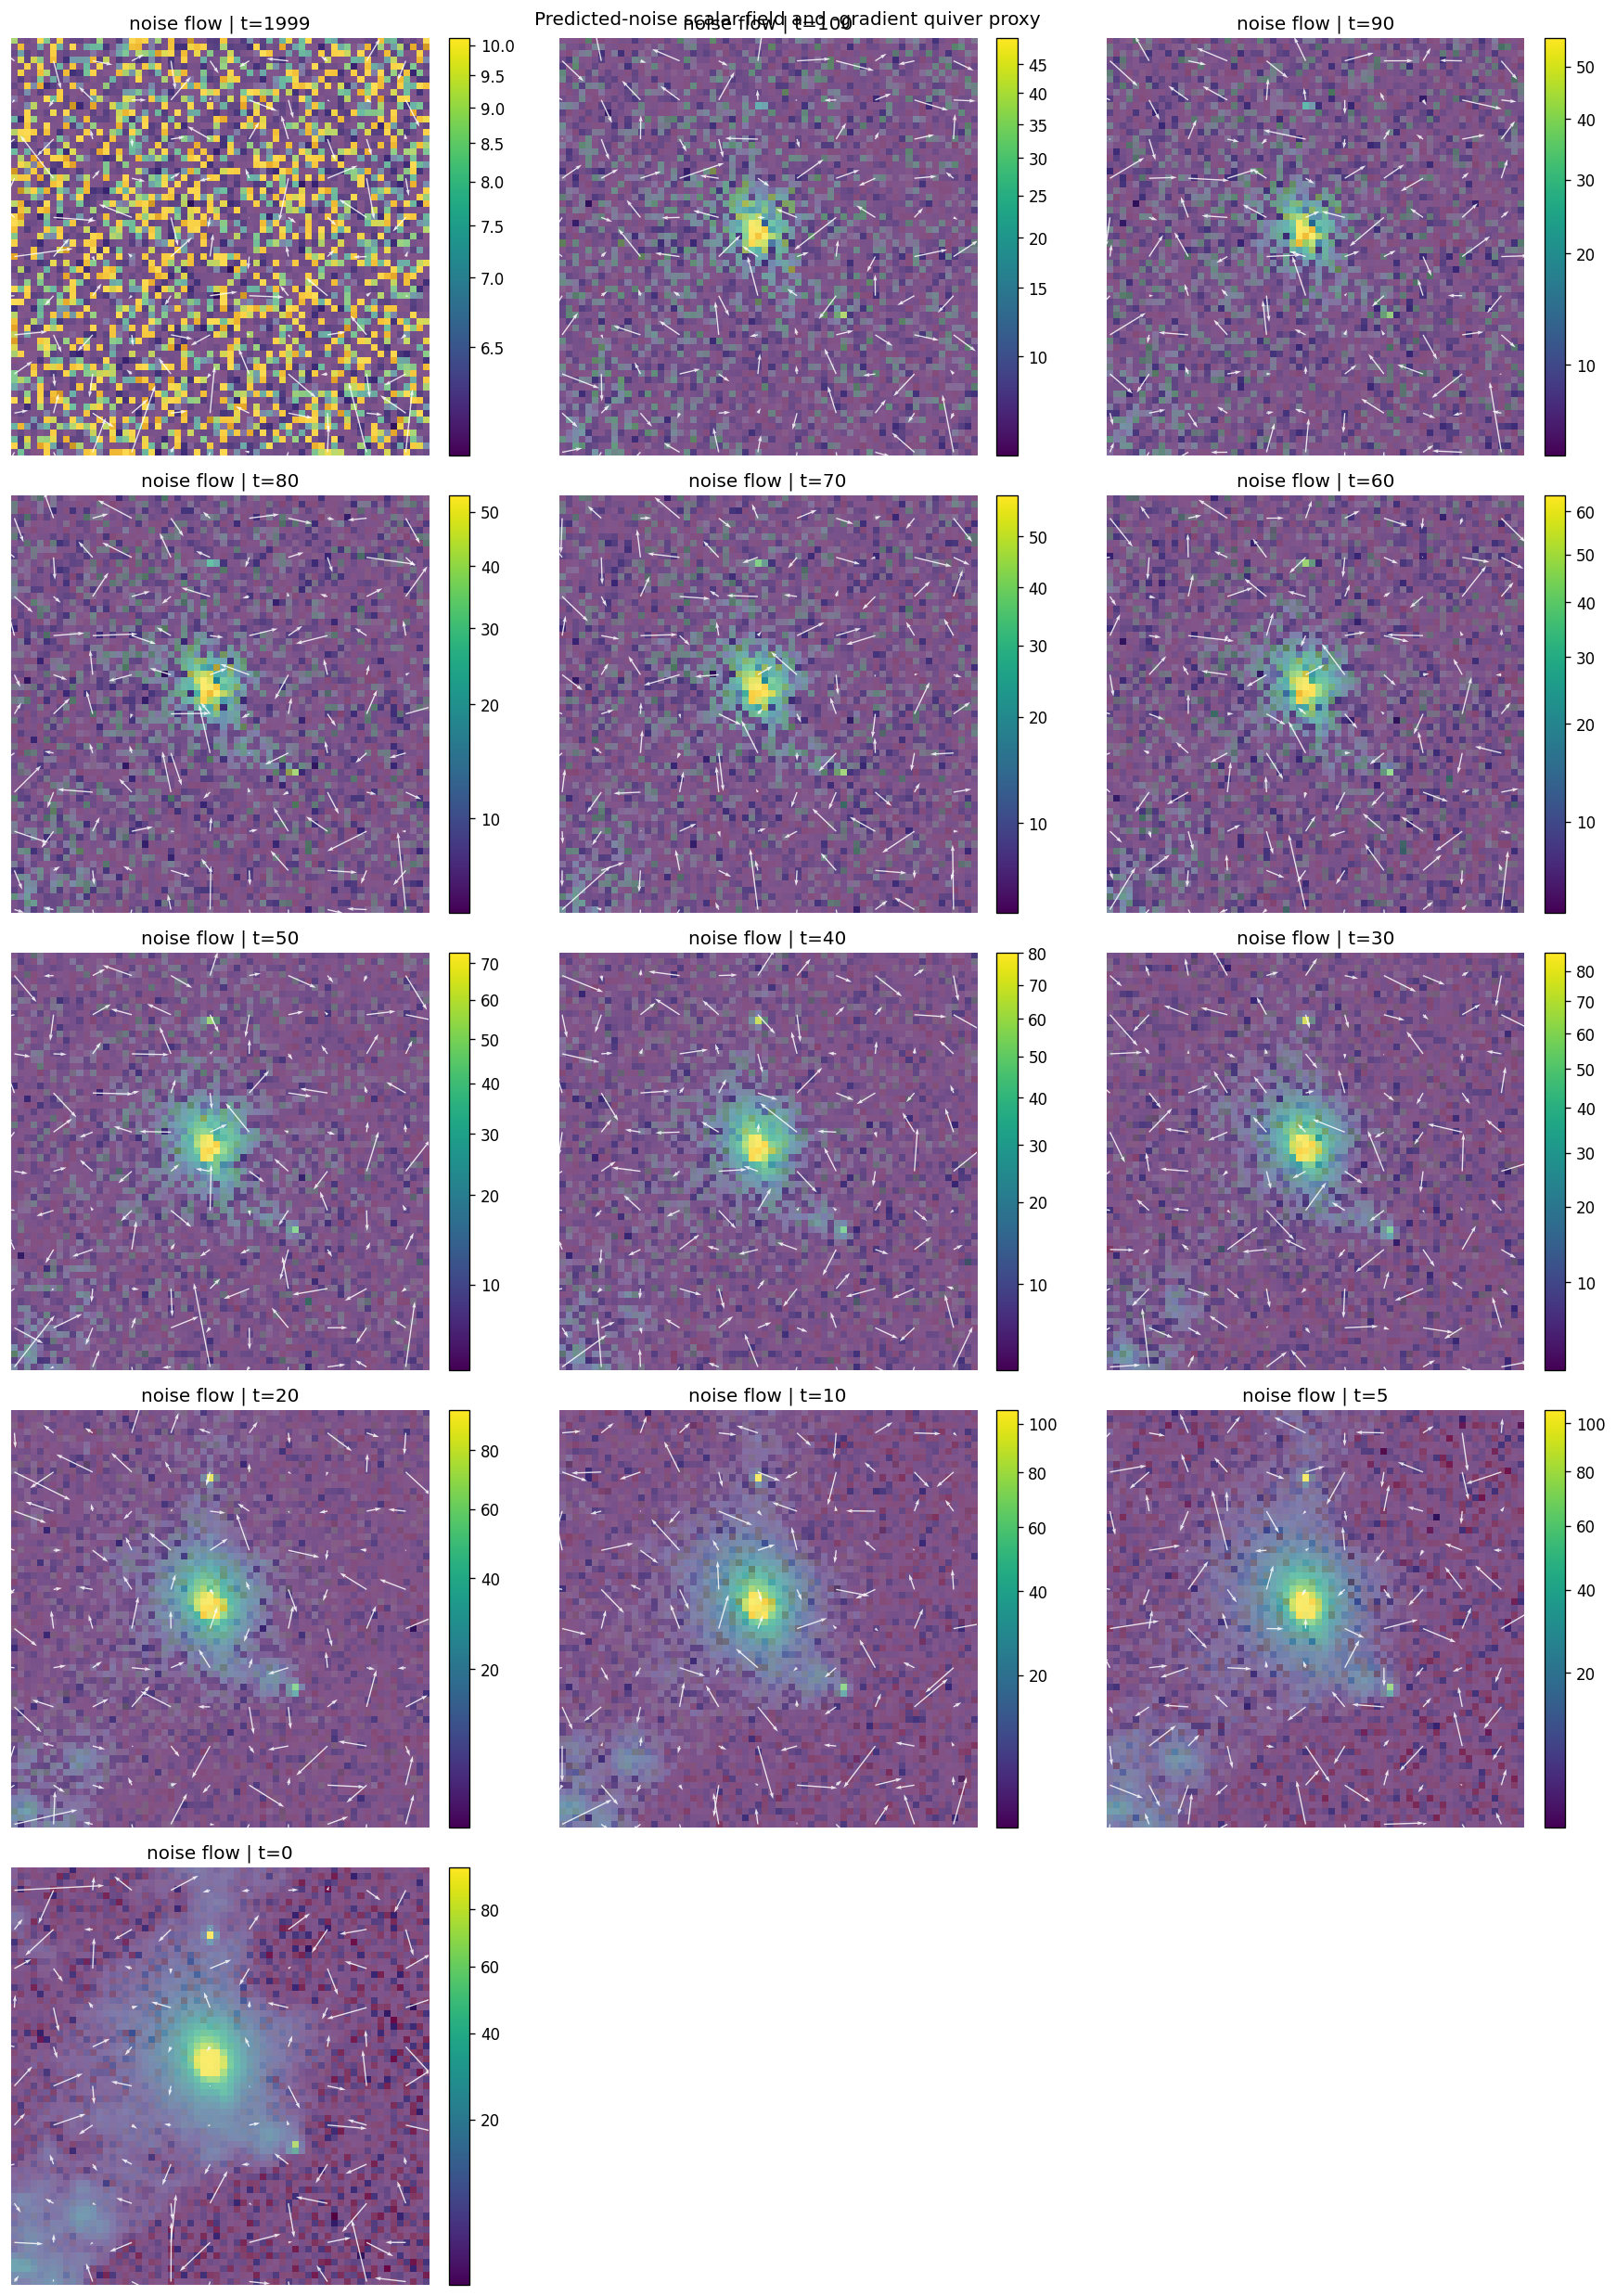

In [9]:
final_levels = contour_levels(trajectory_final_counts)
ncols = 2
nrows = len(ordered_steps)
fig, axes = plt.subplots(nrows, ncols, figsize=(9.5, 3.2 * nrows), squeeze=False)
for row, timestep in enumerate(ordered_steps):
    image = snapshots_counts[timestep]
    residual = image - input_counts_resized
    imshow_counts(axes[row, 0], image, f"x_t counts | t={timestep}", enhanced=True, add_contour=False)
    if len(final_levels) > 0:
        axes[row, 0].contour(trajectory_final_counts, levels=final_levels, origin="lower", colors="white", linestyles="--", linewidths=0.8, alpha=0.9)
    vmax = float(np.nanmax(np.abs(residual))) if np.any(np.isfinite(residual)) else 1.0
    vmax = vmax if vmax > 0 else 1e-6
    im = axes[row, 1].imshow(residual, origin="lower", cmap=VIS_CMAP_RESIDUAL, vmin=-vmax, vmax=vmax, interpolation="nearest")
    axes[row, 1].set_title(f"x_t - input | t={timestep}")
    axes[row, 1].axis("off")
    if len(final_levels) > 0:
        axes[row, 1].contour(trajectory_final_counts, levels=final_levels, origin="lower", colors="black", linestyles="--", linewidths=0.7, alpha=0.8)
    plt.colorbar(im, ax=axes[row, 1], fraction=0.046, pad=0.04)
fig.suptitle("CRAB reverse process snapshots")
fig.tight_layout()
if SAVE_OUTPUTS:
    fig_path = OUTPUT_DIR / f"trajectory_snapshots__{crab_path.stem}__sample{FINAL_SAMPLE_INDEX}__{model_weight_path.stem}.png"
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    print(f"Saved trajectory snapshots: {fig_path}")
plt.show()

if SAVE_PREDICTED_NOISE and noise_predictions:
    cols = min(3, len(noise_predictions))
    rows = math.ceil(len(noise_predictions) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(5.0 * cols, 4.2 * rows), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for ax, timestep in zip(axes.ravel(), ordered_steps):
        if timestep not in noise_predictions:
            continue
        image = snapshots_counts[timestep]
        noise_map = noise_predictions[timestep]
        imshow_counts(ax, image, f"noise flow | t={timestep}", enhanced=True, add_contour=False)
        vmax_noise = float(np.nanmax(np.abs(noise_map))) if np.any(np.isfinite(noise_map)) else 1.0
        vmax_noise = vmax_noise if vmax_noise > 0 else 1e-6
        ax.imshow(noise_map, origin="lower", cmap=VIS_CMAP_NOISE, alpha=0.35, vmin=-vmax_noise, vmax=vmax_noise, interpolation="nearest")
        gy, gx = np.gradient(-noise_map)
        yy, xx = np.mgrid[0:noise_map.shape[0]:QUIVER_STRIDE, 0:noise_map.shape[1]:QUIVER_STRIDE]
        ax.quiver(xx, yy, gx[::QUIVER_STRIDE, ::QUIVER_STRIDE], gy[::QUIVER_STRIDE, ::QUIVER_STRIDE], color="white", angles="xy", scale_units="xy", scale=QUIVER_SCALE, width=0.003, alpha=0.85)
    fig.suptitle("Predicted-noise scalar field and -gradient quiver proxy")
    fig.tight_layout()
    if SAVE_OUTPUTS:
        fig_path = OUTPUT_DIR / f"predicted_noise_quiver__{crab_path.stem}__sample{FINAL_SAMPLE_INDEX}__{model_weight_path.stem}.png"
        fig.savefig(fig_path, dpi=300, bbox_inches="tight")
        print(f"Saved predicted-noise figure: {fig_path}")
    plt.show()


## 6. Final selected reconstruction visualization and FWHM

`FINAL_SAMPLE_INDEX` selects one repeated sample as the final reconstruction. It is visualized with both plain and enhanced styles, using the same style as previous evaluation notebooks but without GT panels.


Saved final plain visualization: /root/LHAI_KM2A/saves/PREDICT/DDPM/CRAB/final_plain__SS433_64_KM2AE25__sample18__Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.png


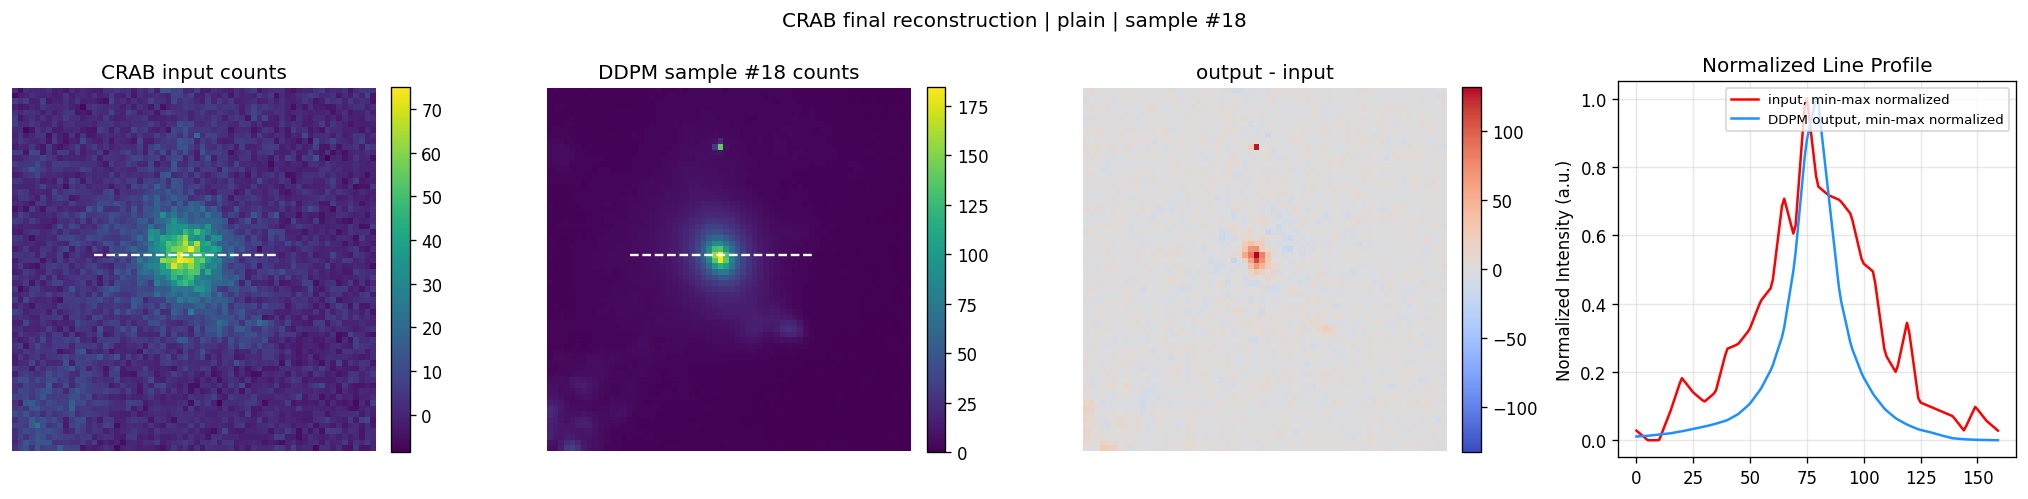

Saved final enhanced visualization: /root/LHAI_KM2A/saves/PREDICT/DDPM/CRAB/final_enhanced__SS433_64_KM2AE25__sample18__Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.png


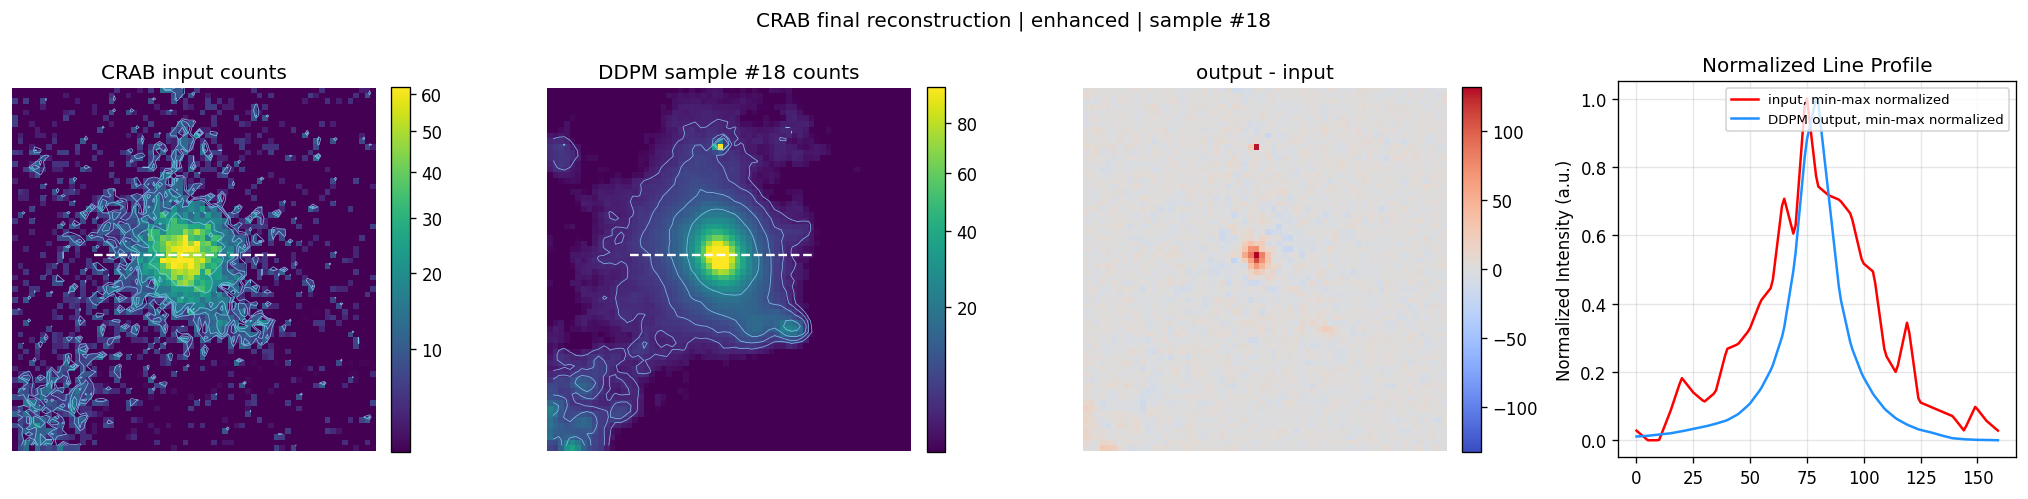

=== FWHM summary [pixels] ===
Input FWHM          : 9.2958 at center=(np.int64(33), np.int64(29))
Final sample FWHM   : 4.6672 at center=(np.int64(34), np.int64(30))
Mean sample FWHM    : 4.8331 at center=(np.int64(34), np.int64(30))


In [10]:
FINAL_SAMPLE_INDEX = 18

if FINAL_SAMPLE_INDEX < 0 or FINAL_SAMPLE_INDEX >= N_SAMPLES:
    raise IndexError(f"FINAL_SAMPLE_INDEX must be in [0, {N_SAMPLES - 1}], got {FINAL_SAMPLE_INDEX}")

final_norm = samples_norm[int(FINAL_SAMPLE_INDEX)]
final_counts = samples_counts[int(FINAL_SAMPLE_INDEX)]


def image2d(array):
    return np.asarray(array).squeeze()


def auto_line_segment(image):
    h, w = image.shape
    y0, x0 = np.unravel_index(int(np.nanargmax(image)), image.shape)
    half = max(4, min(h, w) // 4)
    return max(0, x0 - half), y0, min(w - 1, x0 + half), y0


def line_profile(image, segment, samples=LINE_PROFILE_SAMPLES):
    x1, y1, x2, y2 = segment
    xs = np.linspace(x1, x2, samples)
    ys = np.linspace(y1, y2, samples)
    return map_coordinates(image, [ys, xs], order=1, mode="nearest")


# def normalize_profile_for_display(profile):
#     profile = np.asarray(profile, dtype=np.float64)
#     finite = profile[np.isfinite(profile)]
#     if finite.size == 0:
#         return profile
#     peak = np.nanmax(np.abs(finite))
#     if peak <= 0:
#         return profile
#     return profile / peak

def normalize_profile_for_display(profile):
    """
    Min-Max Normalization (背景扣除后的峰值归一化).
    将背景(底噪)强制对齐到0，峰值对齐到1，以用于公平对比反卷积前后的轮廓形状。
    """
    profile = np.asarray(profile, dtype=np.float64)
    finite = profile[np.isfinite(profile)]
    if finite.size == 0:
        return profile
    
    p_min = np.nanmin(finite)
    p_max = np.nanmax(finite)
    
    # 防止纯平图像导致除以0的报错
    if p_max - p_min <= 0:
        return profile if p_max == 0 else profile / p_max
        
    return (profile - p_min) / (p_max - p_min)


def visualize_final(style="plain"):
    enhanced = style == "enhanced"
    input_img = image2d(input_counts_resized)
    output_img = image2d(final_counts)
    residual = output_img - input_img
    segment = auto_line_segment(output_img) if LINE_SEGMENT is None else LINE_SEGMENT
    fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
    imshow_counts(axes[0], input_img, "CRAB input counts", enhanced=enhanced)
    imshow_counts(axes[1], output_img, f"DDPM sample #{FINAL_SAMPLE_INDEX} counts", enhanced=enhanced)
    vmax = float(np.nanmax(np.abs(residual))) if np.any(np.isfinite(residual)) else 1.0
    vmax = vmax if vmax > 0 else 1e-6
    im = axes[2].imshow(residual, origin="lower", cmap=VIS_CMAP_RESIDUAL, vmin=-vmax, vmax=vmax, interpolation="nearest")
    axes[2].set_title("output - input")
    axes[2].axis("off")
    plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    for ax in axes[:2]:
        x1, y1, x2, y2 = segment
        ax.plot([x1, x2], [y1, y2], linestyle="--", color="white", linewidth=1.4)
    # input_line = normalize_profile_for_display(line_profile(input_img, segment))
    # output_line = normalize_profile_for_display(line_profile(output_img, segment))
    # axes[3].plot(input_line, color="red", label="input, peak-normalized")
    # axes[3].plot(output_line, color="dodgerblue", label="DDPM output, peak-normalized")
    # axes[3].set_title("peak-normalized line profile")
    # axes[3].set_ylabel("I / I_peak")
    # axes[3].legend(fontsize=8)
    # axes[3].grid(True, alpha=0.3)
    input_line = normalize_profile_for_display(line_profile(input_img, segment))
    output_line = normalize_profile_for_display(line_profile(output_img, segment))
    
    axes[3].plot(input_line, color="red", label="input, min-max normalized")
    axes[3].plot(output_line, color="dodgerblue", label="DDPM output, min-max normalized")
    axes[3].set_title("Normalized Line Profile")
    axes[3].set_ylabel("Normalized Intensity (a.u.)") # a.u. 表示任意单位(arbitrary units)，发表常用
    axes[3].legend(fontsize=8)
    axes[3].grid(True, alpha=0.3)
    fig.suptitle(f"CRAB final reconstruction | {style} | sample #{FINAL_SAMPLE_INDEX}")
    fig.tight_layout()
    if SAVE_OUTPUTS:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        fig_path = OUTPUT_DIR / f"final_{style}__{crab_path.stem}__sample{FINAL_SAMPLE_INDEX}__{model_weight_path.stem}.png"
        fig.savefig(fig_path, dpi=300, bbox_inches="tight")
        print(f"Saved final {style} visualization: {fig_path}")
    plt.show()


visualize_final(style="plain")
visualize_final(style="enhanced")

input_center = choose_center(input_counts_resized)
output_center = choose_center(final_counts)
mean_center = choose_center(mean_counts)
input_fwhm = fwhm_from_image(input_counts_resized, input_center, FWHM_RADIAL_BIN_WIDTH)
output_fwhm = fwhm_from_image(final_counts, output_center, FWHM_RADIAL_BIN_WIDTH)
mean_fwhm = fwhm_from_image(mean_counts, mean_center, FWHM_RADIAL_BIN_WIDTH)
print("=== FWHM summary [pixels] ===")
print(f"Input FWHM          : {input_fwhm:.4f} at center={input_center}")
print(f"Final sample FWHM   : {output_fwhm:.4f} at center={output_center}")
print(f"Mean sample FWHM    : {mean_fwhm:.4f} at center={mean_center}")


Saved final plain visualization: /root/LHAI_KM2A/saves/PREDICT/DDPM/CRAB/final_plain__SS433_64_KM2AE25__sample0__Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.png


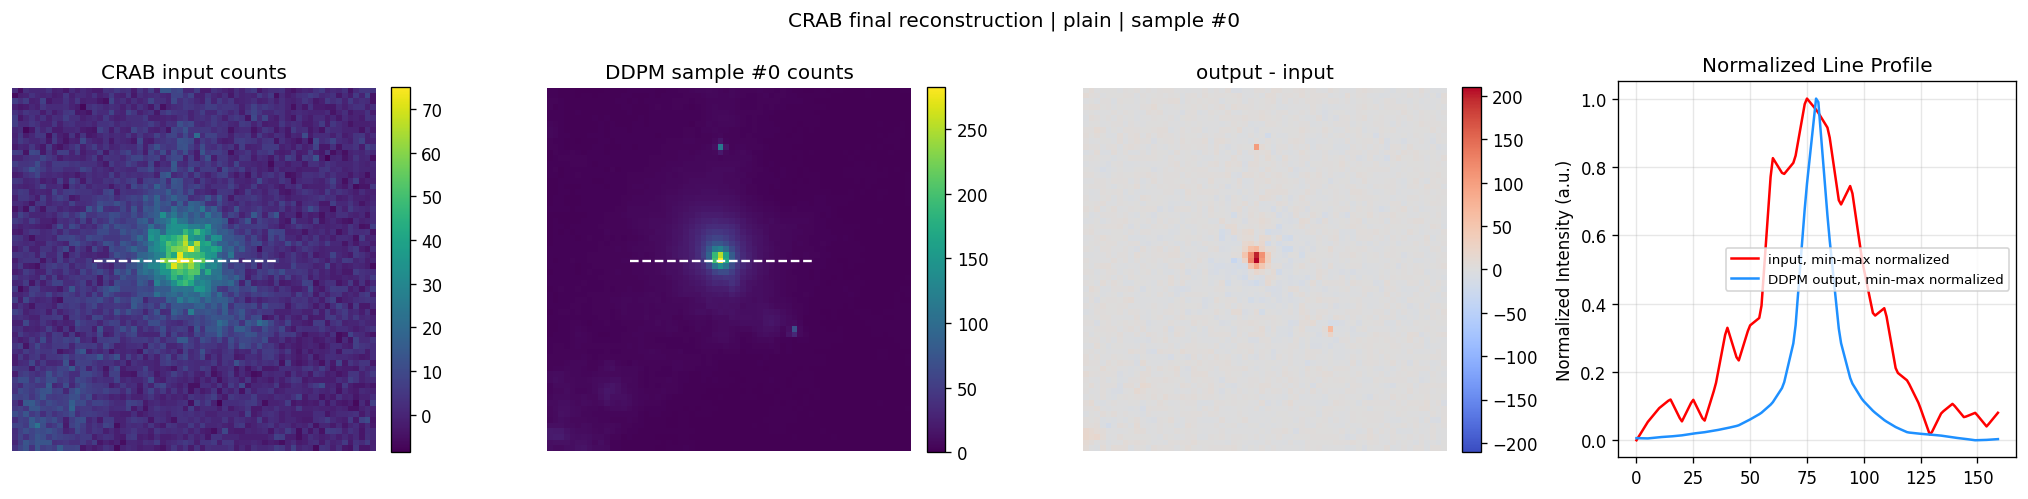

Saved final enhanced visualization: /root/LHAI_KM2A/saves/PREDICT/DDPM/CRAB/final_enhanced__SS433_64_KM2AE25__sample0__Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.png


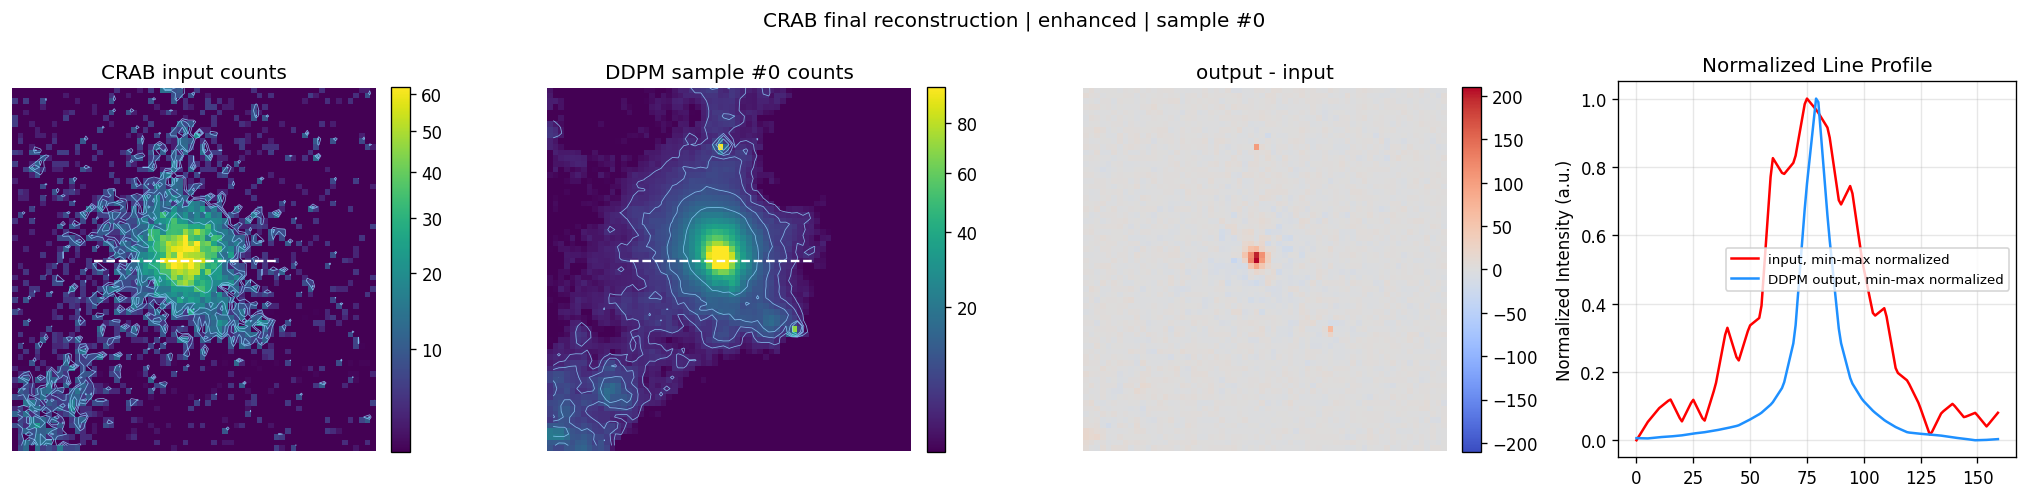

=== FWHM summary [pixels] ===
Input FWHM          : 9.2958 at center=(np.int64(33), np.int64(29))
Final sample FWHM   : 3.5566 at center=(np.int64(33), np.int64(30))
Mean sample FWHM    : 4.8331 at center=(np.int64(34), np.int64(30))


In [11]:
FINAL_SAMPLE_INDEX = 0

if FINAL_SAMPLE_INDEX < 0 or FINAL_SAMPLE_INDEX >= N_SAMPLES:
    raise IndexError(f"FINAL_SAMPLE_INDEX must be in [0, {N_SAMPLES - 1}], got {FINAL_SAMPLE_INDEX}")

final_norm = samples_norm[int(FINAL_SAMPLE_INDEX)]
final_counts = samples_counts[int(FINAL_SAMPLE_INDEX)]


def image2d(array):
    return np.asarray(array).squeeze()


def auto_line_segment(image):
    h, w = image.shape
    y0, x0 = np.unravel_index(int(np.nanargmax(image)), image.shape)
    half = max(4, min(h, w) // 4)
    return max(0, x0 - half), y0, min(w - 1, x0 + half), y0


def line_profile(image, segment, samples=LINE_PROFILE_SAMPLES):
    x1, y1, x2, y2 = segment
    xs = np.linspace(x1, x2, samples)
    ys = np.linspace(y1, y2, samples)
    return map_coordinates(image, [ys, xs], order=1, mode="nearest")


# def normalize_profile_for_display(profile):
#     profile = np.asarray(profile, dtype=np.float64)
#     finite = profile[np.isfinite(profile)]
#     if finite.size == 0:
#         return profile
#     peak = np.nanmax(np.abs(finite))
#     if peak <= 0:
#         return profile
#     return profile / peak

def normalize_profile_for_display(profile):
    """
    Min-Max Normalization (背景扣除后的峰值归一化).
    将背景(底噪)强制对齐到0，峰值对齐到1，以用于公平对比反卷积前后的轮廓形状。
    """
    profile = np.asarray(profile, dtype=np.float64)
    finite = profile[np.isfinite(profile)]
    if finite.size == 0:
        return profile
    
    p_min = np.nanmin(finite)
    p_max = np.nanmax(finite)
    
    # 防止纯平图像导致除以0的报错
    if p_max - p_min <= 0:
        return profile if p_max == 0 else profile / p_max
        
    return (profile - p_min) / (p_max - p_min)


def visualize_final(style="plain"):
    enhanced = style == "enhanced"
    input_img = image2d(input_counts_resized)
    output_img = image2d(final_counts)
    residual = output_img - input_img
    segment = auto_line_segment(output_img) if LINE_SEGMENT is None else LINE_SEGMENT
    fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
    imshow_counts(axes[0], input_img, "CRAB input counts", enhanced=enhanced)
    imshow_counts(axes[1], output_img, f"DDPM sample #{FINAL_SAMPLE_INDEX} counts", enhanced=enhanced)
    vmax = float(np.nanmax(np.abs(residual))) if np.any(np.isfinite(residual)) else 1.0
    vmax = vmax if vmax > 0 else 1e-6
    im = axes[2].imshow(residual, origin="lower", cmap=VIS_CMAP_RESIDUAL, vmin=-vmax, vmax=vmax, interpolation="nearest")
    axes[2].set_title("output - input")
    axes[2].axis("off")
    plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    for ax in axes[:2]:
        x1, y1, x2, y2 = segment
        ax.plot([x1, x2], [y1, y2], linestyle="--", color="white", linewidth=1.4)
    # input_line = normalize_profile_for_display(line_profile(input_img, segment))
    # output_line = normalize_profile_for_display(line_profile(output_img, segment))
    # axes[3].plot(input_line, color="red", label="input, peak-normalized")
    # axes[3].plot(output_line, color="dodgerblue", label="DDPM output, peak-normalized")
    # axes[3].set_title("peak-normalized line profile")
    # axes[3].set_ylabel("I / I_peak")
    # axes[3].legend(fontsize=8)
    # axes[3].grid(True, alpha=0.3)
    input_line = normalize_profile_for_display(line_profile(input_img, segment))
    output_line = normalize_profile_for_display(line_profile(output_img, segment))
    
    axes[3].plot(input_line, color="red", label="input, min-max normalized")
    axes[3].plot(output_line, color="dodgerblue", label="DDPM output, min-max normalized")
    axes[3].set_title("Normalized Line Profile")
    axes[3].set_ylabel("Normalized Intensity (a.u.)") # a.u. 表示任意单位(arbitrary units)，发表常用
    axes[3].legend(fontsize=8)
    axes[3].grid(True, alpha=0.3)
    fig.suptitle(f"CRAB final reconstruction | {style} | sample #{FINAL_SAMPLE_INDEX}")
    fig.tight_layout()
    if SAVE_OUTPUTS:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        fig_path = OUTPUT_DIR / f"final_{style}__{crab_path.stem}__sample{FINAL_SAMPLE_INDEX}__{model_weight_path.stem}.png"
        fig.savefig(fig_path, dpi=300, bbox_inches="tight")
        print(f"Saved final {style} visualization: {fig_path}")
    plt.show()


visualize_final(style="plain")
visualize_final(style="enhanced")

input_center = choose_center(input_counts_resized)
output_center = choose_center(final_counts)
mean_center = choose_center(mean_counts)
input_fwhm = fwhm_from_image(input_counts_resized, input_center, FWHM_RADIAL_BIN_WIDTH)
output_fwhm = fwhm_from_image(final_counts, output_center, FWHM_RADIAL_BIN_WIDTH)
mean_fwhm = fwhm_from_image(mean_counts, mean_center, FWHM_RADIAL_BIN_WIDTH)
print("=== FWHM summary [pixels] ===")
print(f"Input FWHM          : {input_fwhm:.4f} at center={input_center}")
print(f"Final sample FWHM   : {output_fwhm:.4f} at center={output_center}")
print(f"Mean sample FWHM    : {mean_fwhm:.4f} at center={mean_center}")


Saved radial FWHM figure: /root/LHAI_KM2A/saves/PREDICT/DDPM/CRAB/final_radial_fwhm__SS433_64_KM2AE25__sample0__Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.png


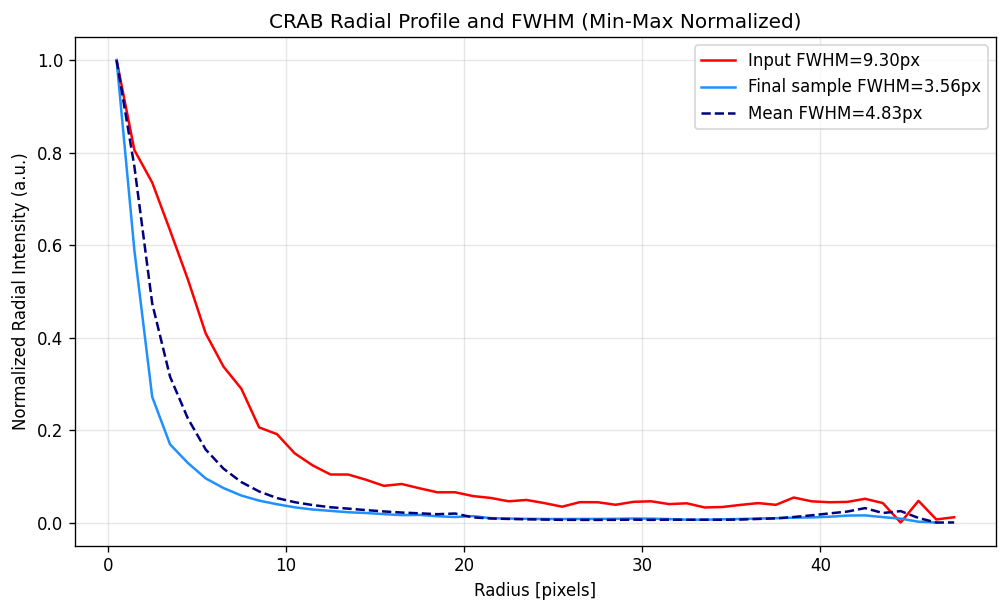

In [12]:
radii_input, profile_input, _ = radial_profile(input_counts_resized, input_center, FWHM_RADIAL_BIN_WIDTH)
radii_output, profile_output, _ = radial_profile(final_counts, output_center, FWHM_RADIAL_BIN_WIDTH)
radii_mean, profile_mean, _ = radial_profile(mean_counts, mean_center, FWHM_RADIAL_BIN_WIDTH)
# profile_input_display = normalize_profile_for_display(profile_input)
# profile_output_display = normalize_profile_for_display(profile_output)
# profile_mean_display = normalize_profile_for_display(profile_mean)
# fig, ax = plt.subplots(figsize=(8.5, 5.2))
# ax.plot(radii_input, profile_input_display, color="red", label=f"Input FWHM={input_fwhm:.2f}px")
# ax.plot(radii_output, profile_output_display, color="dodgerblue", label=f"Final sample FWHM={output_fwhm:.2f}px")
# ax.plot(radii_mean, profile_mean_display, color="navy", linestyle="--", label=f"Mean FWHM={mean_fwhm:.2f}px")
# ax.set_xlabel("Radius [pixels]")
# ax.set_ylabel("Peak-normalized radial intensity")
# ax.set_title("CRAB radial profile and FWHM (profiles peak-normalized for display)")
# ax.grid(True, alpha=0.3)
# ax.legend()
profile_input_display = normalize_profile_for_display(profile_input)
profile_output_display = normalize_profile_for_display(profile_output)
profile_mean_display = normalize_profile_for_display(profile_mean)

fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.plot(radii_input, profile_input_display, color="red", label=f"Input FWHM={input_fwhm:.2f}px")
ax.plot(radii_output, profile_output_display, color="dodgerblue", label=f"Final sample FWHM={output_fwhm:.2f}px")
ax.plot(radii_mean, profile_mean_display, color="navy", linestyle="--", label=f"Mean FWHM={mean_fwhm:.2f}px")

ax.set_xlabel("Radius [pixels]")
ax.set_ylabel("Normalized Radial Intensity (a.u.)")
ax.set_title("CRAB Radial Profile and FWHM (Min-Max Normalized)")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
if SAVE_OUTPUTS:
    fig_path = OUTPUT_DIR / f"final_radial_fwhm__{crab_path.stem}__sample{FINAL_SAMPLE_INDEX}__{model_weight_path.stem}.png"
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    print(f"Saved radial FWHM figure: {fig_path}")
plt.show()

## 7. Save arrays and metadata


In [13]:
summary = {
    "crab_path": str(crab_path),
    "model_weight_path": str(model_weight_path),
    "diffusion_config_key": DIFFUSION_CONFIG_KEY,
    "energy_range": ENERGY_RANGE,
    "roi_description": ROI_DESCRIPTION,
    "data_range": DATA_RANGE,
    "n_samples": int(N_SAMPLES),
    "base_seed": int(BASE_SEED),
    "final_sample_index": int(FINAL_SAMPLE_INDEX),
    "snapshot_steps": [int(step) for step in ordered_steps],
    "counts_restore_mode": COUNTS_RESTORE_MODE,
    "input_flux_counts": float(image_flux(input_counts_resized)),
    "final_flux_counts": float(image_flux(final_counts)),
    "mean_flux_counts": float(image_flux(mean_counts)),
    "input_fwhm_pixels": float(input_fwhm),
    "final_sample_fwhm_pixels": float(output_fwhm),
    "mean_sample_fwhm_pixels": float(mean_fwhm),
    "mean_uncertainty_counts": float(np.nanmean(std_counts)),
    "median_relative_uncertainty": float(np.nanmedian(relative_std)),
    "created_at": datetime.now().isoformat(timespec="seconds"),
}
print(json.dumps(summary, ensure_ascii=False, indent=2))

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    stem = f"{crab_path.stem}__{model_weight_path.stem}"
    np.save(OUTPUT_DIR / f"samples_norm__{stem}.npy", samples_norm.astype(np.float32))
    np.save(OUTPUT_DIR / f"samples_counts__{stem}.npy", samples_counts.astype(np.float32))
    np.save(OUTPUT_DIR / f"mean_counts__{stem}.npy", mean_counts.astype(np.float32))
    np.save(OUTPUT_DIR / f"std_counts__{stem}.npy", std_counts.astype(np.float32))
    np.save(OUTPUT_DIR / f"final_sample_counts__{stem}__idx{FINAL_SAMPLE_INDEX}.npy", final_counts.astype(np.float32))
    np.savez_compressed(
        OUTPUT_DIR / f"trajectory_snapshots__{stem}__sample{FINAL_SAMPLE_INDEX}.npz",
        timesteps=np.asarray(ordered_steps, dtype=np.int32),
        snapshots_norm=np.stack([snapshots_norm[t] for t in ordered_steps]).astype(np.float32),
        snapshots_counts=np.stack([snapshots_counts[t] for t in ordered_steps]).astype(np.float32),
        predicted_noise=np.stack([noise_predictions[t] for t in ordered_steps if t in noise_predictions]).astype(np.float32) if noise_predictions else np.empty((0,), dtype=np.float32),
        flux_curve=flux_curve.astype(np.float64),
        fwhm_curve=fwhm_curve.astype(np.float64),
    )
    summary_path = OUTPUT_DIR / f"crab_prediction_summary__{stem}.json"
    summary_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"Saved arrays and summary under: {OUTPUT_DIR}")


{
  "crab_path": "/root/LHAI_KM2A/data/CRAB/SS433_64_KM2AE25.npy",
  "model_weight_path": "/root/LHAI_KM2A/saves/MODEL/DDPM/Last_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.pth",
  "diffusion_config_key": "DDPM_64",
  "energy_range": "1TeV~10TeV",
  "roi_description": "6.4 deg square centered at CRAB; source-map construction follows LHAASO CRAB experimental data",
  "data_range": 2.0,
  "n_samples": 20,
  "base_seed": 2026,
  "final_sample_index": 0,
  "snapshot_steps": [
    1999,
    100,
    90,
    80,
    70,
    60,
    50,
    40,
    30,
    20,
    10,
    5,
    0
  ],
  "counts_restore_mode": "input_mass_match",
  "input_flux_counts": 20696.251953125,
  "final_flux_counts": 20696.25390625,
  "mean_flux_counts": 20696.251953125,
  "input_fwhm_pixels": 9.295783314526096,
  "final_sample_fwhm_pixels": 3.556624040544718,
  "mean_sample_fwhm_pixels": 4.833060479058715,
  "mean_uncertainty_counts": 1.2933135032653809,
  "median_relative_uncertainty": 0.39557135105133057,
  "cre